In [2]:
# ------------------------------------------------------------
# 1. CONNECT GOOGLE DRIVE
# ------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ------------------------------------------------------------
# 2. IMPORT LIBRARIES
# ------------------------------------------------------------
import os
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [4]:

# ------------------------------------------------------------
# 3. FILE PATHS
# ------------------------------------------------------------
TRAIN_PATH = "/content/drive/MyDrive/dataset_A_training.csv"
TEST_PATH = "/content/drive/MyDrive/dataset_A_testing.csv"

BASE_FOLDER = "/content/drive/MyDrive/Hackathon"
EDA_FOLDER = f"{BASE_FOLDER}/EDA"

os.makedirs(EDA_FOLDER, exist_ok=True)

ID_COLUMN = "respondent_id"
TARGET_COLUMN = "seasonal_vaccine"


In [5]:
# ------------------------------------------------------------
# 4. HELPER FUNCTIONS
# ------------------------------------------------------------
def save_and_show(filename):
    """
    Save the active matplotlib figure to Google Drive and display it.
    """
    path = f"{EDA_FOLDER}/{filename}"
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", path)


def create_axes(number_of_plots, columns=3, width=6, height=4):
    """
    Create a subplot grid and return flattened axes.
    """
    rows = math.ceil(number_of_plots / columns)

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(columns * width, rows * height)
    )

    axes = np.array(axes).reshape(-1)

    return fig, axes


def remove_unused_axes(axes, number_of_plots):
    """
    Hide unused subplot panels.
    """
    for axis in axes[number_of_plots:]:
        axis.axis("off")


In [6]:

# ------------------------------------------------------------
# 5. LOAD DATA
# ------------------------------------------------------------
if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(f"Training file not found: {TRAIN_PATH}")

if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(f"Testing file not found: {TEST_PATH}")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Clean accidental spaces in column names
train_df.columns = train_df.columns.astype(str).str.strip()
test_df.columns = test_df.columns.astype(str).str.strip()

# Automatically swap files if paths are reversed
if TARGET_COLUMN not in train_df.columns and TARGET_COLUMN in test_df.columns:
    print("Warning: Files were reversed. Swapping them automatically.")
    train_df, test_df = test_df, train_df

In [7]:

# ------------------------------------------------------------
# 6. STRICT DATA CHECKS
# ------------------------------------------------------------
if TARGET_COLUMN not in train_df.columns:
    raise ValueError(
        f"Training data must contain '{TARGET_COLUMN}'."
    )

if TARGET_COLUMN in test_df.columns:
    raise ValueError(
        f"Testing data must not contain '{TARGET_COLUMN}'."
    )

if ID_COLUMN not in train_df.columns:
    raise ValueError(
        f"Training data must contain '{ID_COLUMN}'."
    )

if ID_COLUMN not in test_df.columns:
    raise ValueError(
        f"Testing data must contain '{ID_COLUMN}'."
    )

if train_df[TARGET_COLUMN].isnull().any():
    raise ValueError(
        "The target column contains missing values."
    )

if not set(train_df[TARGET_COLUMN].unique()).issubset({0, 1}):
    raise ValueError(
        "The target column must contain only 0 and 1."
    )

print("\n============================================================")
print("DATASET LOADED SUCCESSFULLY")
print("============================================================")

print("\nTraining shape:", train_df.shape)
print("Testing shape :", test_df.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nTesting columns:")
print(test_df.columns.tolist())



DATASET LOADED SUCCESSFULLY

Training shape: (4756, 31)
Testing shape : (4749, 30)

Training columns:
['respondent_id', 'flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'household_adults', 'household_children', 'employment_sector', 'seasonal_vaccine']

Testing columns:
['respondent_id', 'flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'docto

In [8]:
# ------------------------------------------------------------
# 7. PREPARE FEATURE DATA
# respondent_id is excluded from EDA feature analysis
# ------------------------------------------------------------
X = train_df.drop(columns=[ID_COLUMN, TARGET_COLUMN])
y = train_df[TARGET_COLUMN].astype(int)

X_test = test_df.drop(columns=[ID_COLUMN])

if set(X.columns) != set(X_test.columns):
    missing_in_test = sorted(set(X.columns) - set(X_test.columns))
    extra_in_test = sorted(set(X_test.columns) - set(X.columns))

    raise ValueError(
        "Training and testing feature columns do not match.\n"
        f"Missing in testing data: {missing_in_test}\n"
        f"Extra in testing data: {extra_in_test}"
    )

X_test = X_test[X.columns]

numeric_columns = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("\nNumber of predictors:", X.shape[1])
print("Numeric predictors  :", len(numeric_columns))
print("Categorical predictors:", len(categorical_columns))


Number of predictors: 29
Numeric predictors  : 19
Categorical predictors: 10


In [9]:
# ------------------------------------------------------------
# 8. DATA-QUALITY REPORT
# ------------------------------------------------------------
quality_report = pd.DataFrame({
    "training_dtype": X.dtypes.astype(str),
    "testing_dtype": X_test.dtypes.astype(str),
    "training_unique_values": X.nunique(dropna=True),
    "testing_unique_values": X_test.nunique(dropna=True),
    "training_missing_values": X.isnull().sum(),
    "testing_missing_values": X_test.isnull().sum()
})

quality_report["training_missing_percentage"] = (
    quality_report["training_missing_values"] /
    len(X) * 100
).round(2)

quality_report["testing_missing_percentage"] = (
    quality_report["testing_missing_values"] /
    len(X_test) * 100
).round(2)

quality_report["combined_missing_values"] = (
    quality_report["training_missing_values"] +
    quality_report["testing_missing_values"]
)

quality_report = quality_report.sort_values(
    by="combined_missing_values",
    ascending=False
)

quality_report.to_csv(
    f"{EDA_FOLDER}/01_data_quality_report.csv",
    index=True
)

print("\n============================================================")
print("DATA-QUALITY CHECKS")
print("============================================================")

print("\nDuplicate respondent IDs in training data:",
      int(train_df[ID_COLUMN].duplicated().sum()))

print("Duplicate respondent IDs in testing data :",
      int(test_df[ID_COLUMN].duplicated().sum()))

print("\nDuplicate training rows:",
      int(train_df.duplicated().sum()))

print("Duplicate testing rows :",
      int(test_df.duplicated().sum()))

print("\nTotal missing predictor values in training data:",
      int(X.isnull().sum().sum()))

print("Total missing predictor values in testing data :",
      int(X_test.isnull().sum().sum()))

print("\nFeature-level data-quality report:")
print(quality_report.to_string())


DATA-QUALITY CHECKS

Duplicate respondent IDs in training data: 0
Duplicate respondent IDs in testing data : 0

Duplicate training rows: 0
Duplicate testing rows : 0

Total missing predictor values in training data: 7538
Total missing predictor values in testing data : 7772

Feature-level data-quality report:
                            training_dtype testing_dtype  training_unique_values  testing_unique_values  training_missing_values  testing_missing_values  training_missing_percentage  testing_missing_percentage  combined_missing_values
employment_sector                   object        object                      21                     21                     2314                    2405                        48.65                       50.64                     4719
health_insurance                   float64       float64                       2                      2                     1925                    1982                        40.48                       41.74         

In [10]:
# ------------------------------------------------------------
# 9. MISSING-VALUES TABLE
# ------------------------------------------------------------
missing_summary = quality_report[
    quality_report["combined_missing_values"] > 0
][[
    "training_missing_values",
    "testing_missing_values",
    "training_missing_percentage",
    "testing_missing_percentage",
    "combined_missing_values"
]]

missing_summary.to_csv(
    f"{EDA_FOLDER}/02_missing_values_summary.csv",
    index=True
)

print("\n============================================================")
print("MISSING-VALUES SUMMARY")
print("============================================================")

print(missing_summary.to_string())



MISSING-VALUES SUMMARY
                             training_missing_values  testing_missing_values  training_missing_percentage  testing_missing_percentage  combined_missing_values
employment_sector                               2314                    2405                        48.65                       50.64                     4719
health_insurance                                1925                    1982                        40.48                       41.74                     3907
income_poverty                                   790                     797                        16.61                       16.78                     1587
rent_or_own                                      381                     379                         8.01                        7.98                      760
doctor_recc_seasonal                             321                     345                         6.75                        7.26                      666
employment_status     

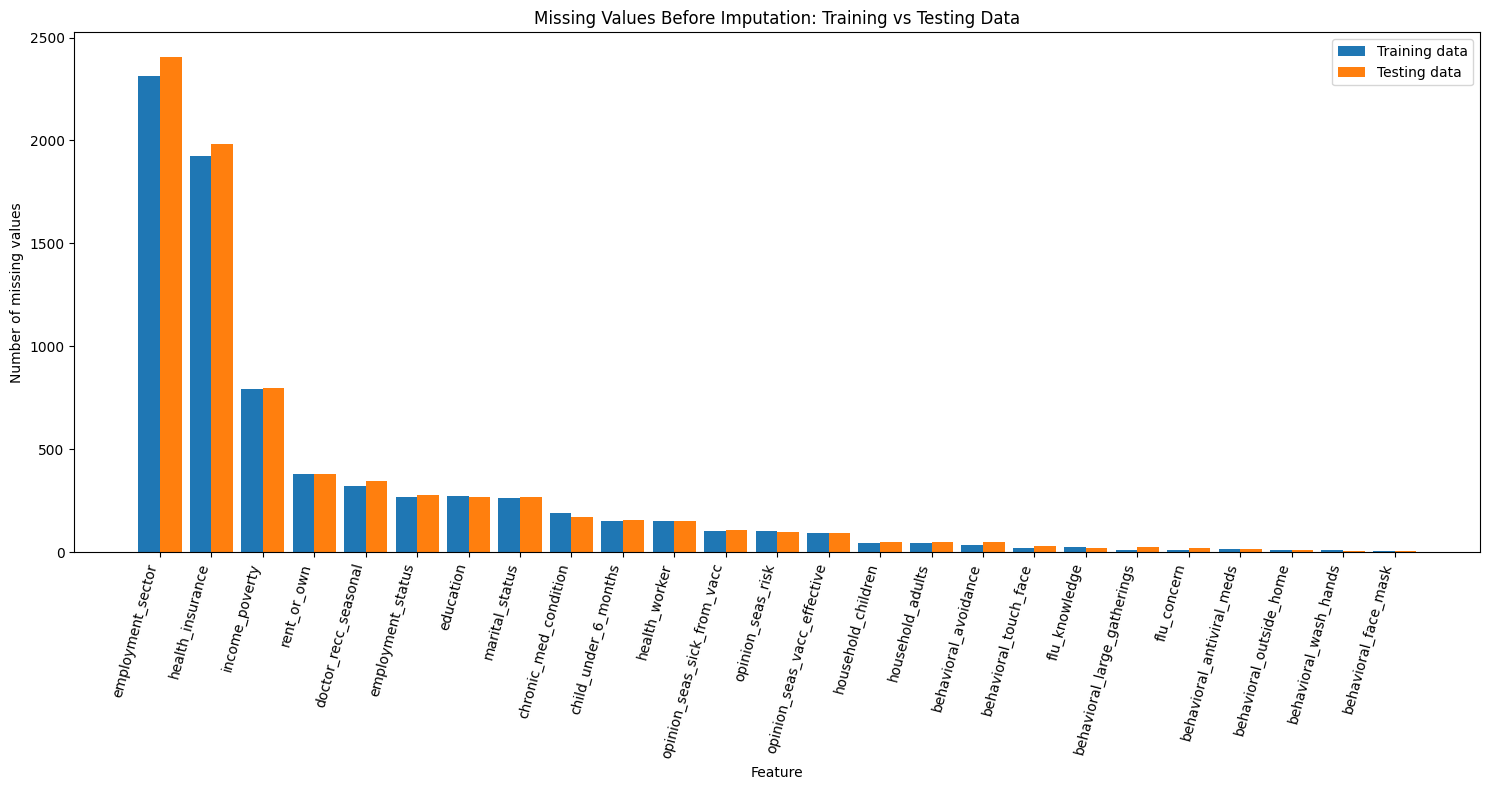

Saved: /content/drive/MyDrive/Hackathon/EDA/03_missing_values_training_vs_testing.png


In [11]:
# ------------------------------------------------------------
# 10. MISSING-VALUES PLOT: TRAINING VS TESTING
# ------------------------------------------------------------
plt.figure(figsize=(15, 8))

x_positions = np.arange(len(missing_summary))
bar_width = 0.42

plt.bar(
    x_positions - bar_width / 2,
    missing_summary["training_missing_values"],
    width=bar_width,
    label="Training data"
)

plt.bar(
    x_positions + bar_width / 2,
    missing_summary["testing_missing_values"],
    width=bar_width,
    label="Testing data"
)

plt.xticks(
    x_positions,
    missing_summary.index,
    rotation=75,
    ha="right"
)

plt.xlabel("Feature")
plt.ylabel("Number of missing values")
plt.title("Missing Values Before Imputation: Training vs Testing Data")
plt.legend()

save_and_show("03_missing_values_training_vs_testing.png")

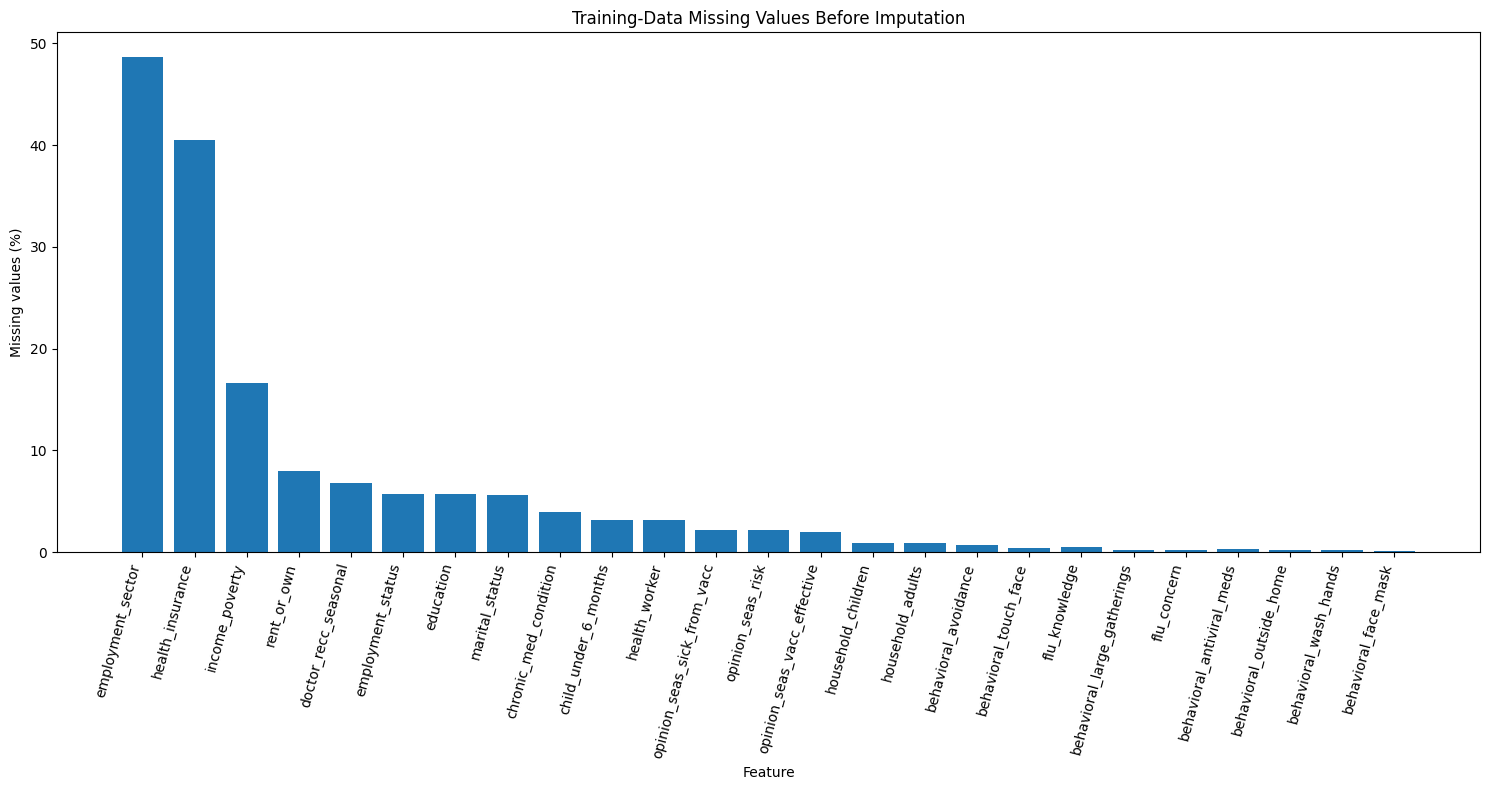

Saved: /content/drive/MyDrive/Hackathon/EDA/04_training_missing_percentage.png


In [12]:
# ------------------------------------------------------------
# 11. MISSING-PERCENTAGE PLOT
# ------------------------------------------------------------
plt.figure(figsize=(15, 8))

plt.bar(
    missing_summary.index,
    missing_summary["training_missing_percentage"]
)

plt.xticks(
    rotation=75,
    ha="right"
)

plt.xlabel("Feature")
plt.ylabel("Missing values (%)")
plt.title("Training-Data Missing Values Before Imputation")

save_and_show("04_training_missing_percentage.png")

In [13]:
# ------------------------------------------------------------
# 12. TARGET DISTRIBUTION TABLE
# ------------------------------------------------------------
target_summary = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "percentage": (
        y.value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

target_summary.index = [
    "No seasonal vaccine (0)",
    "Seasonal vaccine (1)"
]

target_summary.to_csv(
    f"{EDA_FOLDER}/05_target_distribution.csv",
    index=True
)

print("\n============================================================")
print("TARGET DISTRIBUTION")
print("============================================================")

print(target_summary.to_string())



TARGET DISTRIBUTION
                         count  percentage
No seasonal vaccine (0)   2205       46.36
Seasonal vaccine (1)      2551       53.64


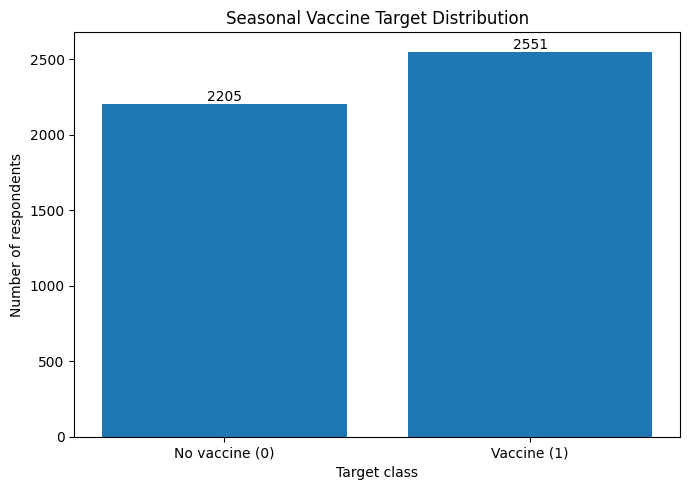

Saved: /content/drive/MyDrive/Hackathon/EDA/06_target_distribution.png


In [14]:
# ------------------------------------------------------------
# 13. TARGET DISTRIBUTION PLOT
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["No vaccine (0)", "Vaccine (1)"],
    y.value_counts().sort_index().values
)

plt.xlabel("Target class")
plt.ylabel("Number of respondents")
plt.title("Seasonal Vaccine Target Distribution")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

save_and_show("06_target_distribution.png")


In [15]:
# ------------------------------------------------------------
# 14. NUMERIC SUMMARY STATISTICS
# ------------------------------------------------------------
numeric_summary = X[numeric_columns].describe().T

numeric_summary["missing_values"] = (
    X[numeric_columns].isnull().sum()
)

numeric_summary["missing_percentage"] = (
    numeric_summary["missing_values"] /
    len(X) * 100
).round(2)

numeric_summary["unique_values"] = (
    X[numeric_columns].nunique(dropna=True)
)

numeric_summary.to_csv(
    f"{EDA_FOLDER}/07_numeric_summary_statistics.csv",
    index=True
)

print("\n============================================================")
print("NUMERIC SUMMARY STATISTICS")
print("============================================================")

print(numeric_summary.to_string())


NUMERIC SUMMARY STATISTICS
                              count      mean       std  min  25%  50%  75%  max  missing_values  missing_percentage  unique_values
flu_concern                  4744.0  1.643128  0.919810  0.0  1.0  2.0  2.0  3.0              12                0.25              4
flu_knowledge                4733.0  1.293049  0.618902  0.0  1.0  1.0  2.0  2.0              23                0.48              3
behavioral_antiviral_meds    4742.0  0.052299  0.222652  0.0  0.0  0.0  0.0  1.0              14                0.29              2
behavioral_avoidance         4724.0  0.734124  0.441846  0.0  0.0  1.0  1.0  1.0              32                0.67              2
behavioral_face_mask         4753.0  0.073848  0.261551  0.0  0.0  0.0  0.0  1.0               3                0.06              2
behavioral_wash_hands        4748.0  0.836563  0.369803  0.0  1.0  1.0  1.0  1.0               8                0.17              2
behavioral_large_gatherings  4747.0  0.365494  0

In [16]:
# ------------------------------------------------------------
# 15. CATEGORICAL SUMMARY STATISTICS
# ------------------------------------------------------------
categorical_rows = []

for column in categorical_columns:
    mode_values = X[column].mode(dropna=True)

    most_frequent_value = (
        mode_values.iloc[0]
        if len(mode_values) > 0
        else np.nan
    )

    most_frequent_count = (
        int(X[column].value_counts(dropna=True).iloc[0])
        if X[column].notnull().any()
        else 0
    )

    categorical_rows.append({
        "feature": column,
        "unique_values": X[column].nunique(dropna=True),
        "missing_values": X[column].isnull().sum(),
        "missing_percentage": round(
            X[column].isnull().mean() * 100,
            2
        ),
        "most_frequent_value": most_frequent_value,
        "most_frequent_count": most_frequent_count
    })

categorical_summary = pd.DataFrame(
    categorical_rows
).set_index("feature")

categorical_summary.to_csv(
    f"{EDA_FOLDER}/08_categorical_summary_statistics.csv",
    index=True
)

print("\n============================================================")
print("CATEGORICAL SUMMARY STATISTICS")
print("============================================================")

print(categorical_summary.to_string())


CATEGORICAL SUMMARY STATISTICS
                   unique_values  missing_values  missing_percentage        most_frequent_value  most_frequent_count
feature                                                                                                             
age_group                      5               0                0.00                  65+ Years                 1169
education                      4             270                5.68           College Graduate                 1879
race                           4               0                0.00                      White                 3766
sex                            2               0                0.00                     Female                 2783
income_poverty                 3             790               16.61  <= $75,000, Above Poverty                 2258
marital_status                 2             265                5.57                    Married                 2403
rent_or_own                    2

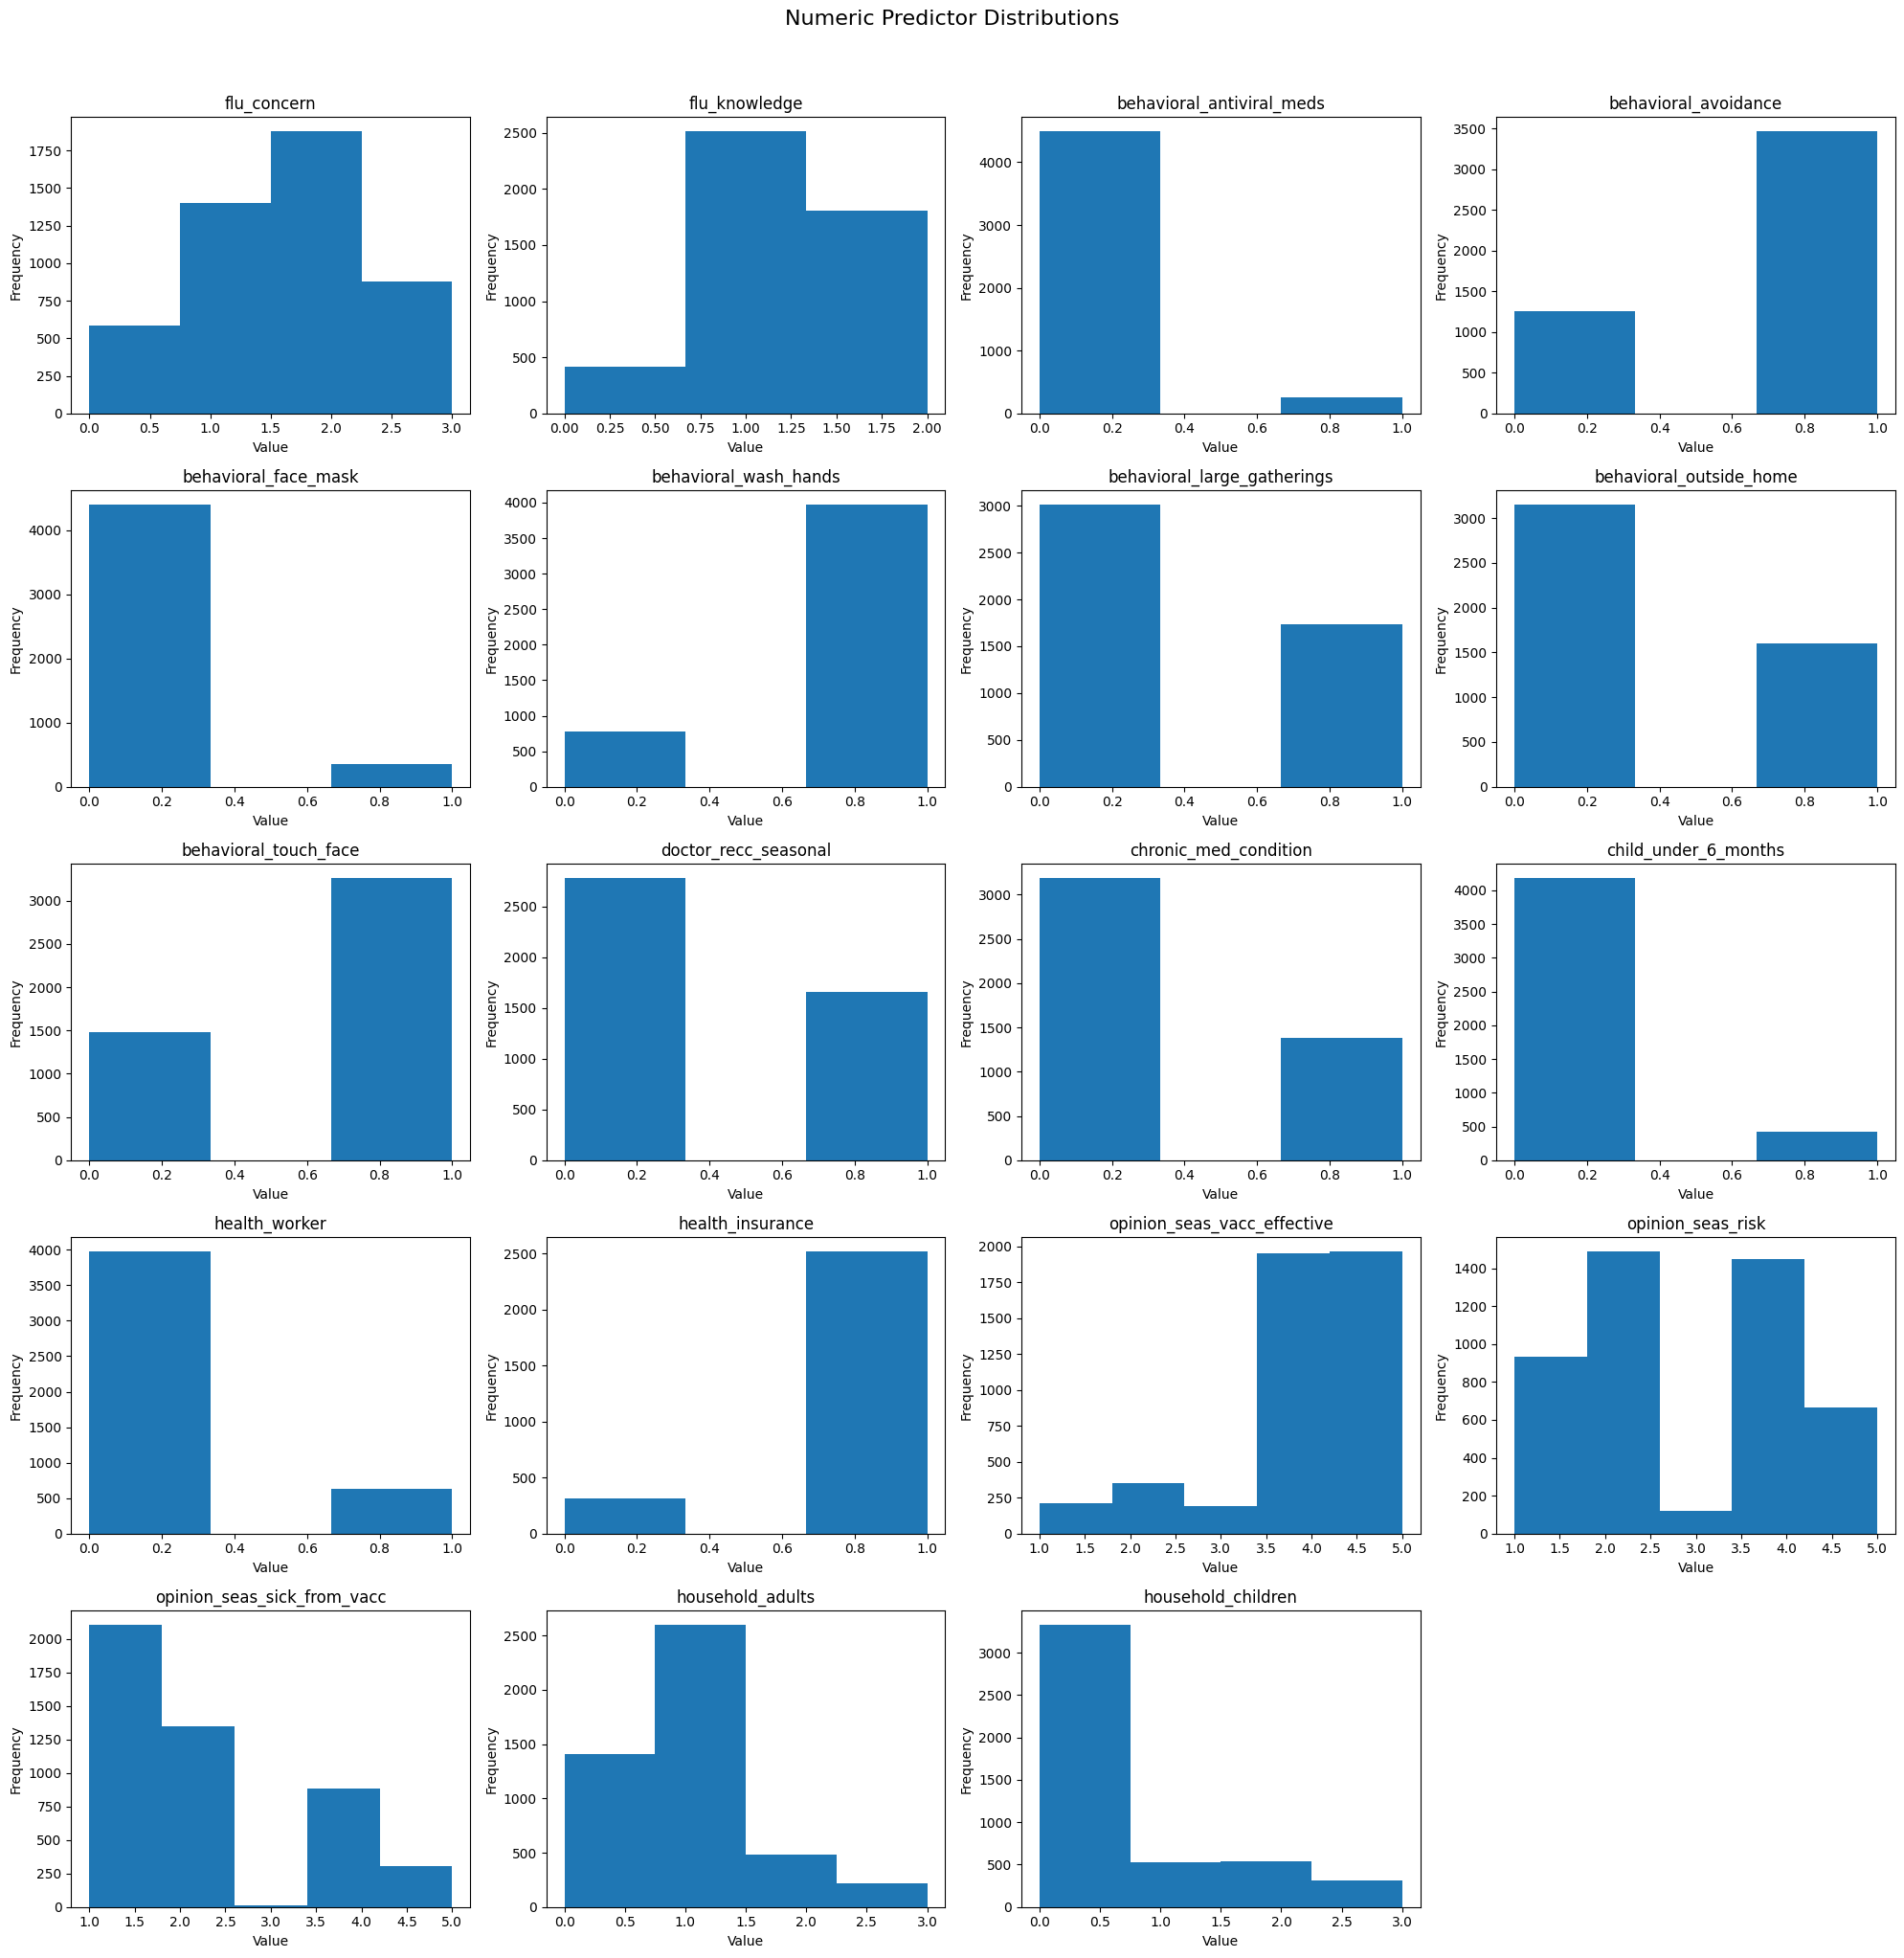

Saved: /content/drive/MyDrive/Hackathon/EDA/09_numeric_feature_distributions.png


In [17]:
# ------------------------------------------------------------
# 16. NUMERIC FEATURE DISTRIBUTION PLOTS
# ------------------------------------------------------------
fig, axes = create_axes(
    number_of_plots=len(numeric_columns),
    columns=4,
    width=5,
    height=4
)

for axis, column in zip(axes, numeric_columns):
    axis.hist(
        X[column].dropna(),
        bins=min(15, max(3, X[column].nunique(dropna=True)))
    )

    axis.set_title(column)
    axis.set_xlabel("Value")
    axis.set_ylabel("Frequency")

remove_unused_axes(
    axes,
    len(numeric_columns)
)

plt.suptitle(
    "Numeric Predictor Distributions",
    fontsize=16,
    y=1.02
)

save_and_show("09_numeric_feature_distributions.png")

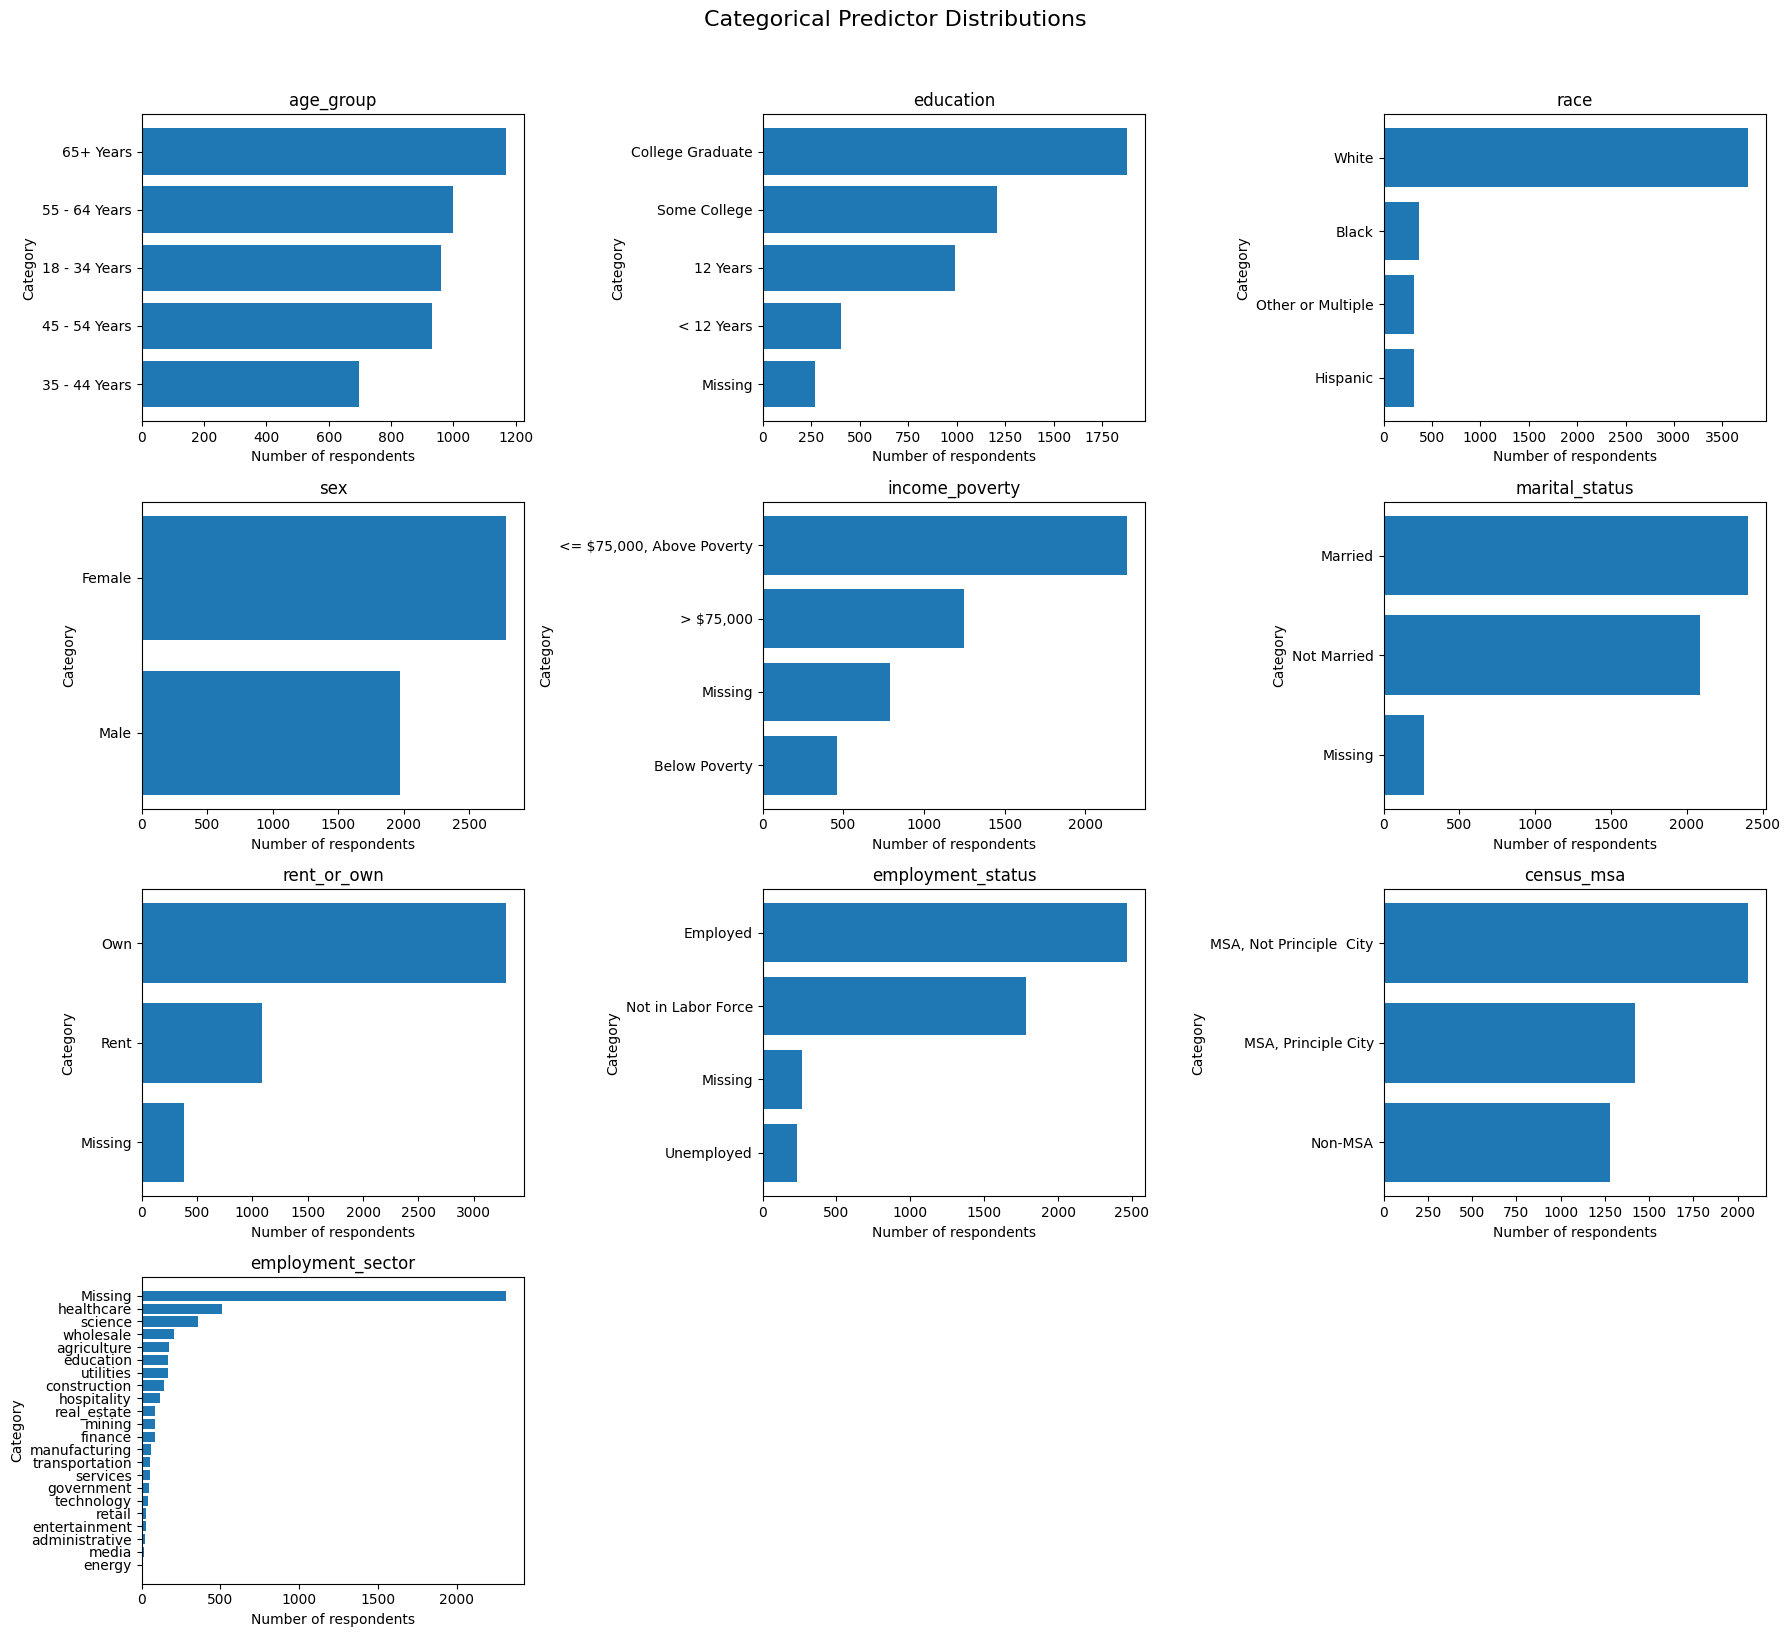

Saved: /content/drive/MyDrive/Hackathon/EDA/10_categorical_feature_distributions.png


In [19]:
# ------------------------------------------------------------
# 17. CATEGORICAL FEATURE DISTRIBUTION PLOTS
# ------------------------------------------------------------
fig, axes = create_axes(
    number_of_plots=len(categorical_columns),
    columns=3,
    width=6,
    height=4
)

for axis, column in zip(axes, categorical_columns):
    counts = (
        X[column]
        .fillna("Missing")
        .astype(str)
        .value_counts()
        .sort_values(ascending=True)
    )

    axis.barh(
        counts.index,
        counts.values
    )

    axis.set_title(column)
    axis.set_xlabel("Number of respondents")
    axis.set_ylabel("Category")

remove_unused_axes(
    axes,
    len(categorical_columns)
)

plt.suptitle(
    "Categorical Predictor Distributions",
    fontsize=16,
    y=1.02
)

save_and_show("10_categorical_feature_distributions.png")

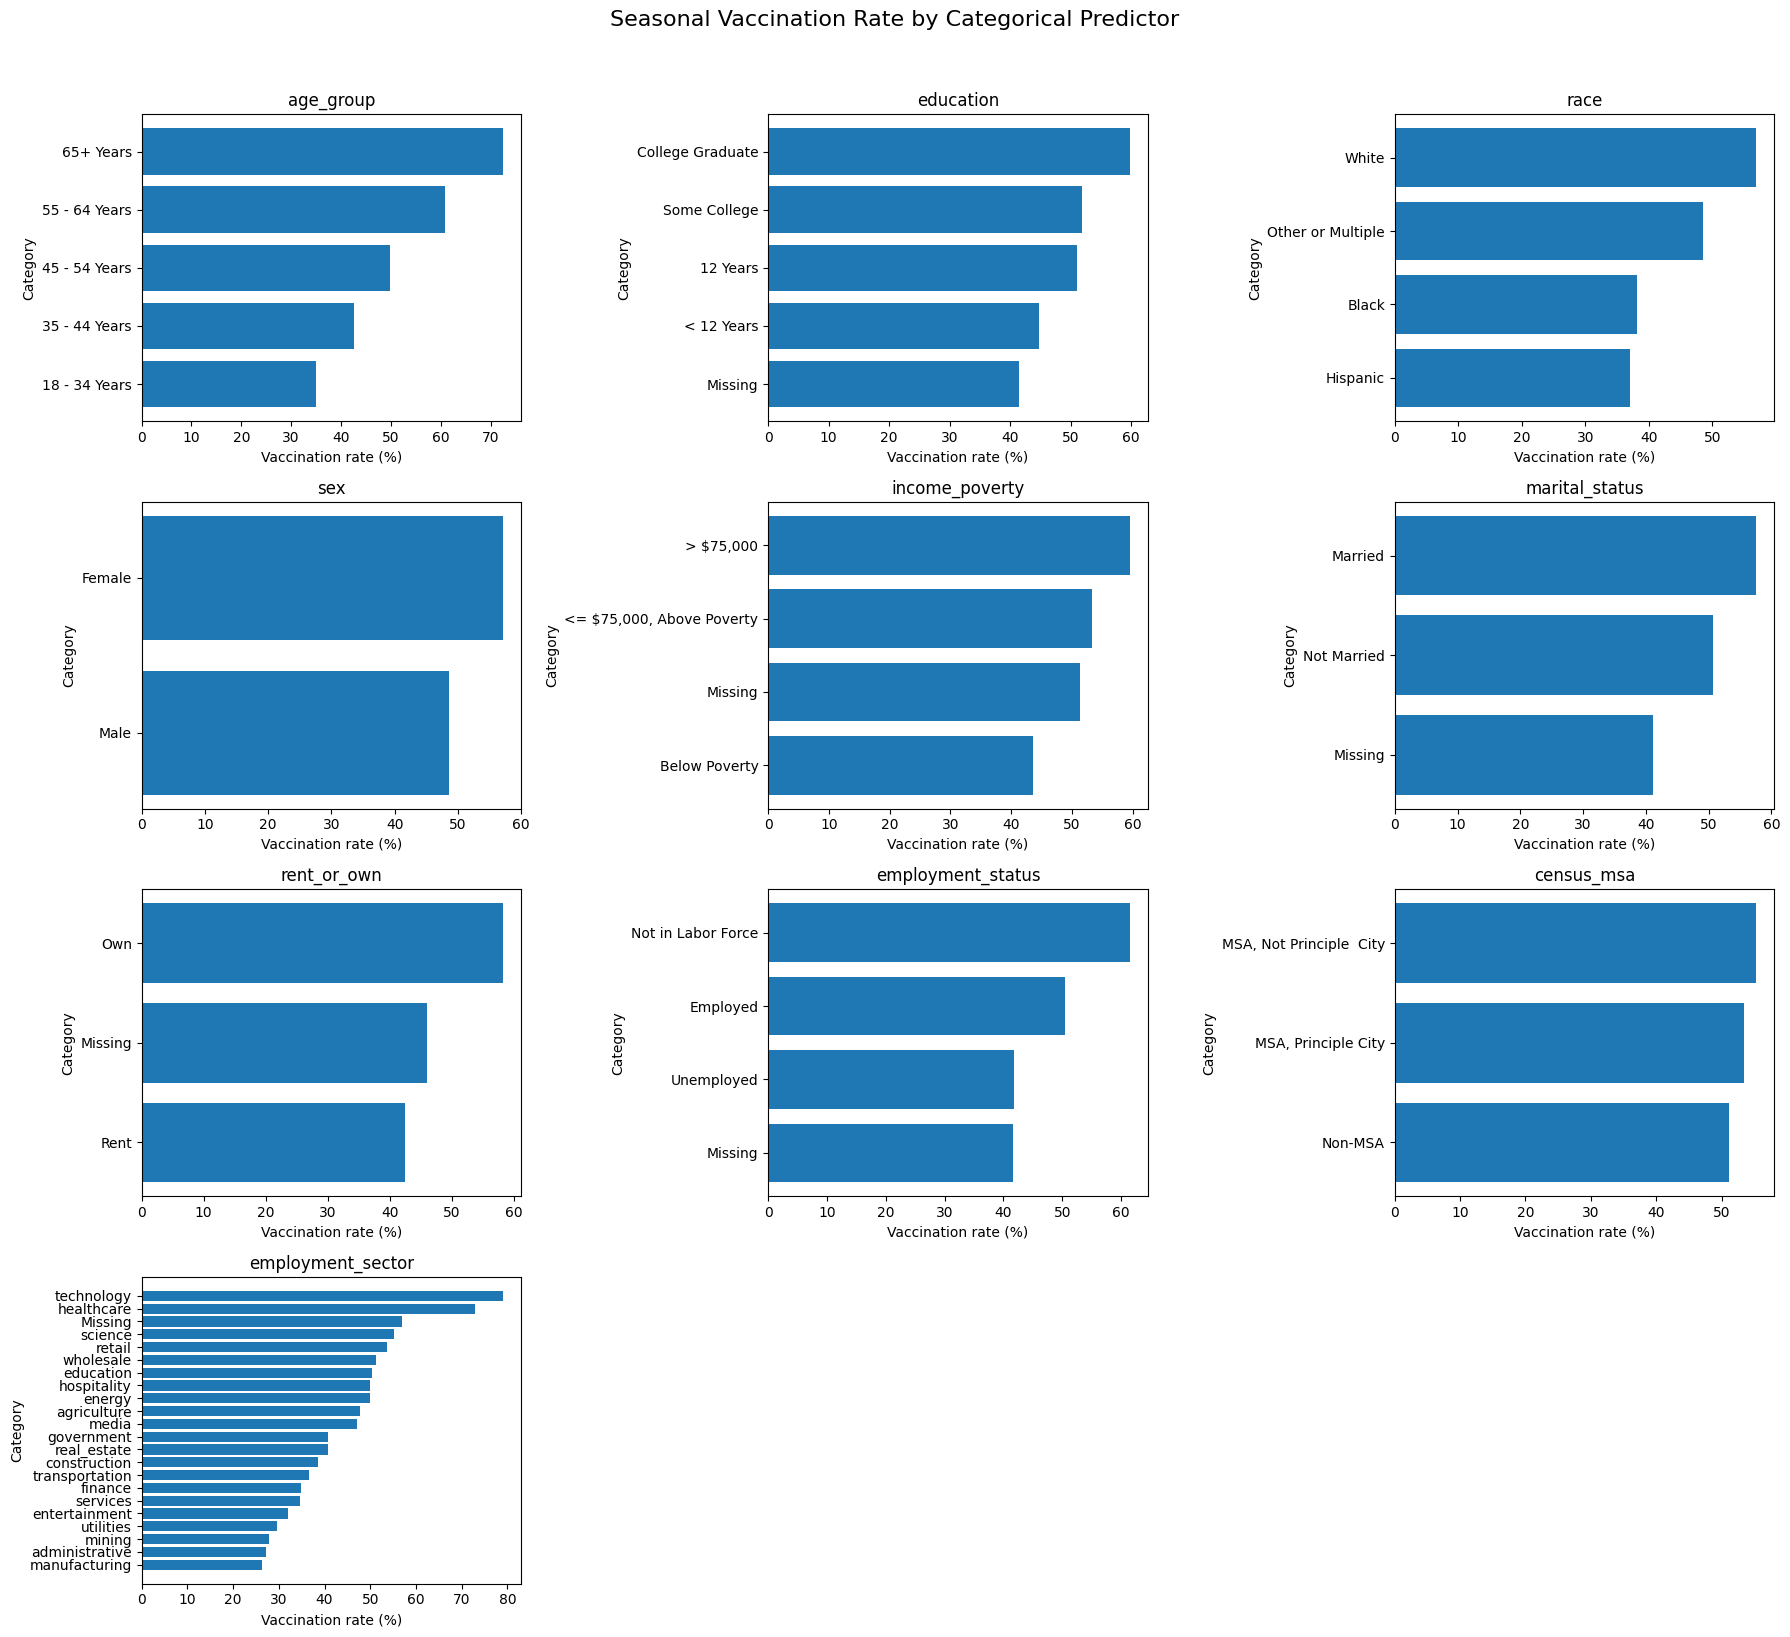

Saved: /content/drive/MyDrive/Hackathon/EDA/11_vaccination_rate_by_categorical_feature.png


In [20]:
# ------------------------------------------------------------
# 18. TARGET RATE BY CATEGORICAL FEATURE
# ------------------------------------------------------------
fig, axes = create_axes(
    number_of_plots=len(categorical_columns),
    columns=3,
    width=6,
    height=4
)

categorical_rate_tables = []

for axis, column in zip(axes, categorical_columns):

    analysis_df = pd.DataFrame({
        column: X[column].fillna("Missing").astype(str),
        TARGET_COLUMN: y
    })

    vaccination_rate = (
        analysis_df
        .groupby(column)[TARGET_COLUMN]
        .agg(["mean", "count"])
        .sort_values("mean")
    )

    vaccination_rate["vaccination_rate_percentage"] = (
        vaccination_rate["mean"] * 100
    ).round(2)

    vaccination_rate["feature"] = column

    categorical_rate_tables.append(
        vaccination_rate.reset_index()
    )

    axis.barh(
        vaccination_rate.index,
        vaccination_rate["vaccination_rate_percentage"]
    )

    axis.set_title(column)
    axis.set_xlabel("Vaccination rate (%)")
    axis.set_ylabel("Category")

remove_unused_axes(
    axes,
    len(categorical_columns)
)

plt.suptitle(
    "Seasonal Vaccination Rate by Categorical Predictor",
    fontsize=16,
    y=1.02
)

save_and_show("11_vaccination_rate_by_categorical_feature.png")

categorical_rate_summary = pd.concat(
    categorical_rate_tables,
    ignore_index=True
)

categorical_rate_summary.to_csv(
    f"{EDA_FOLDER}/12_vaccination_rate_by_categorical_feature.csv",
    index=False
)

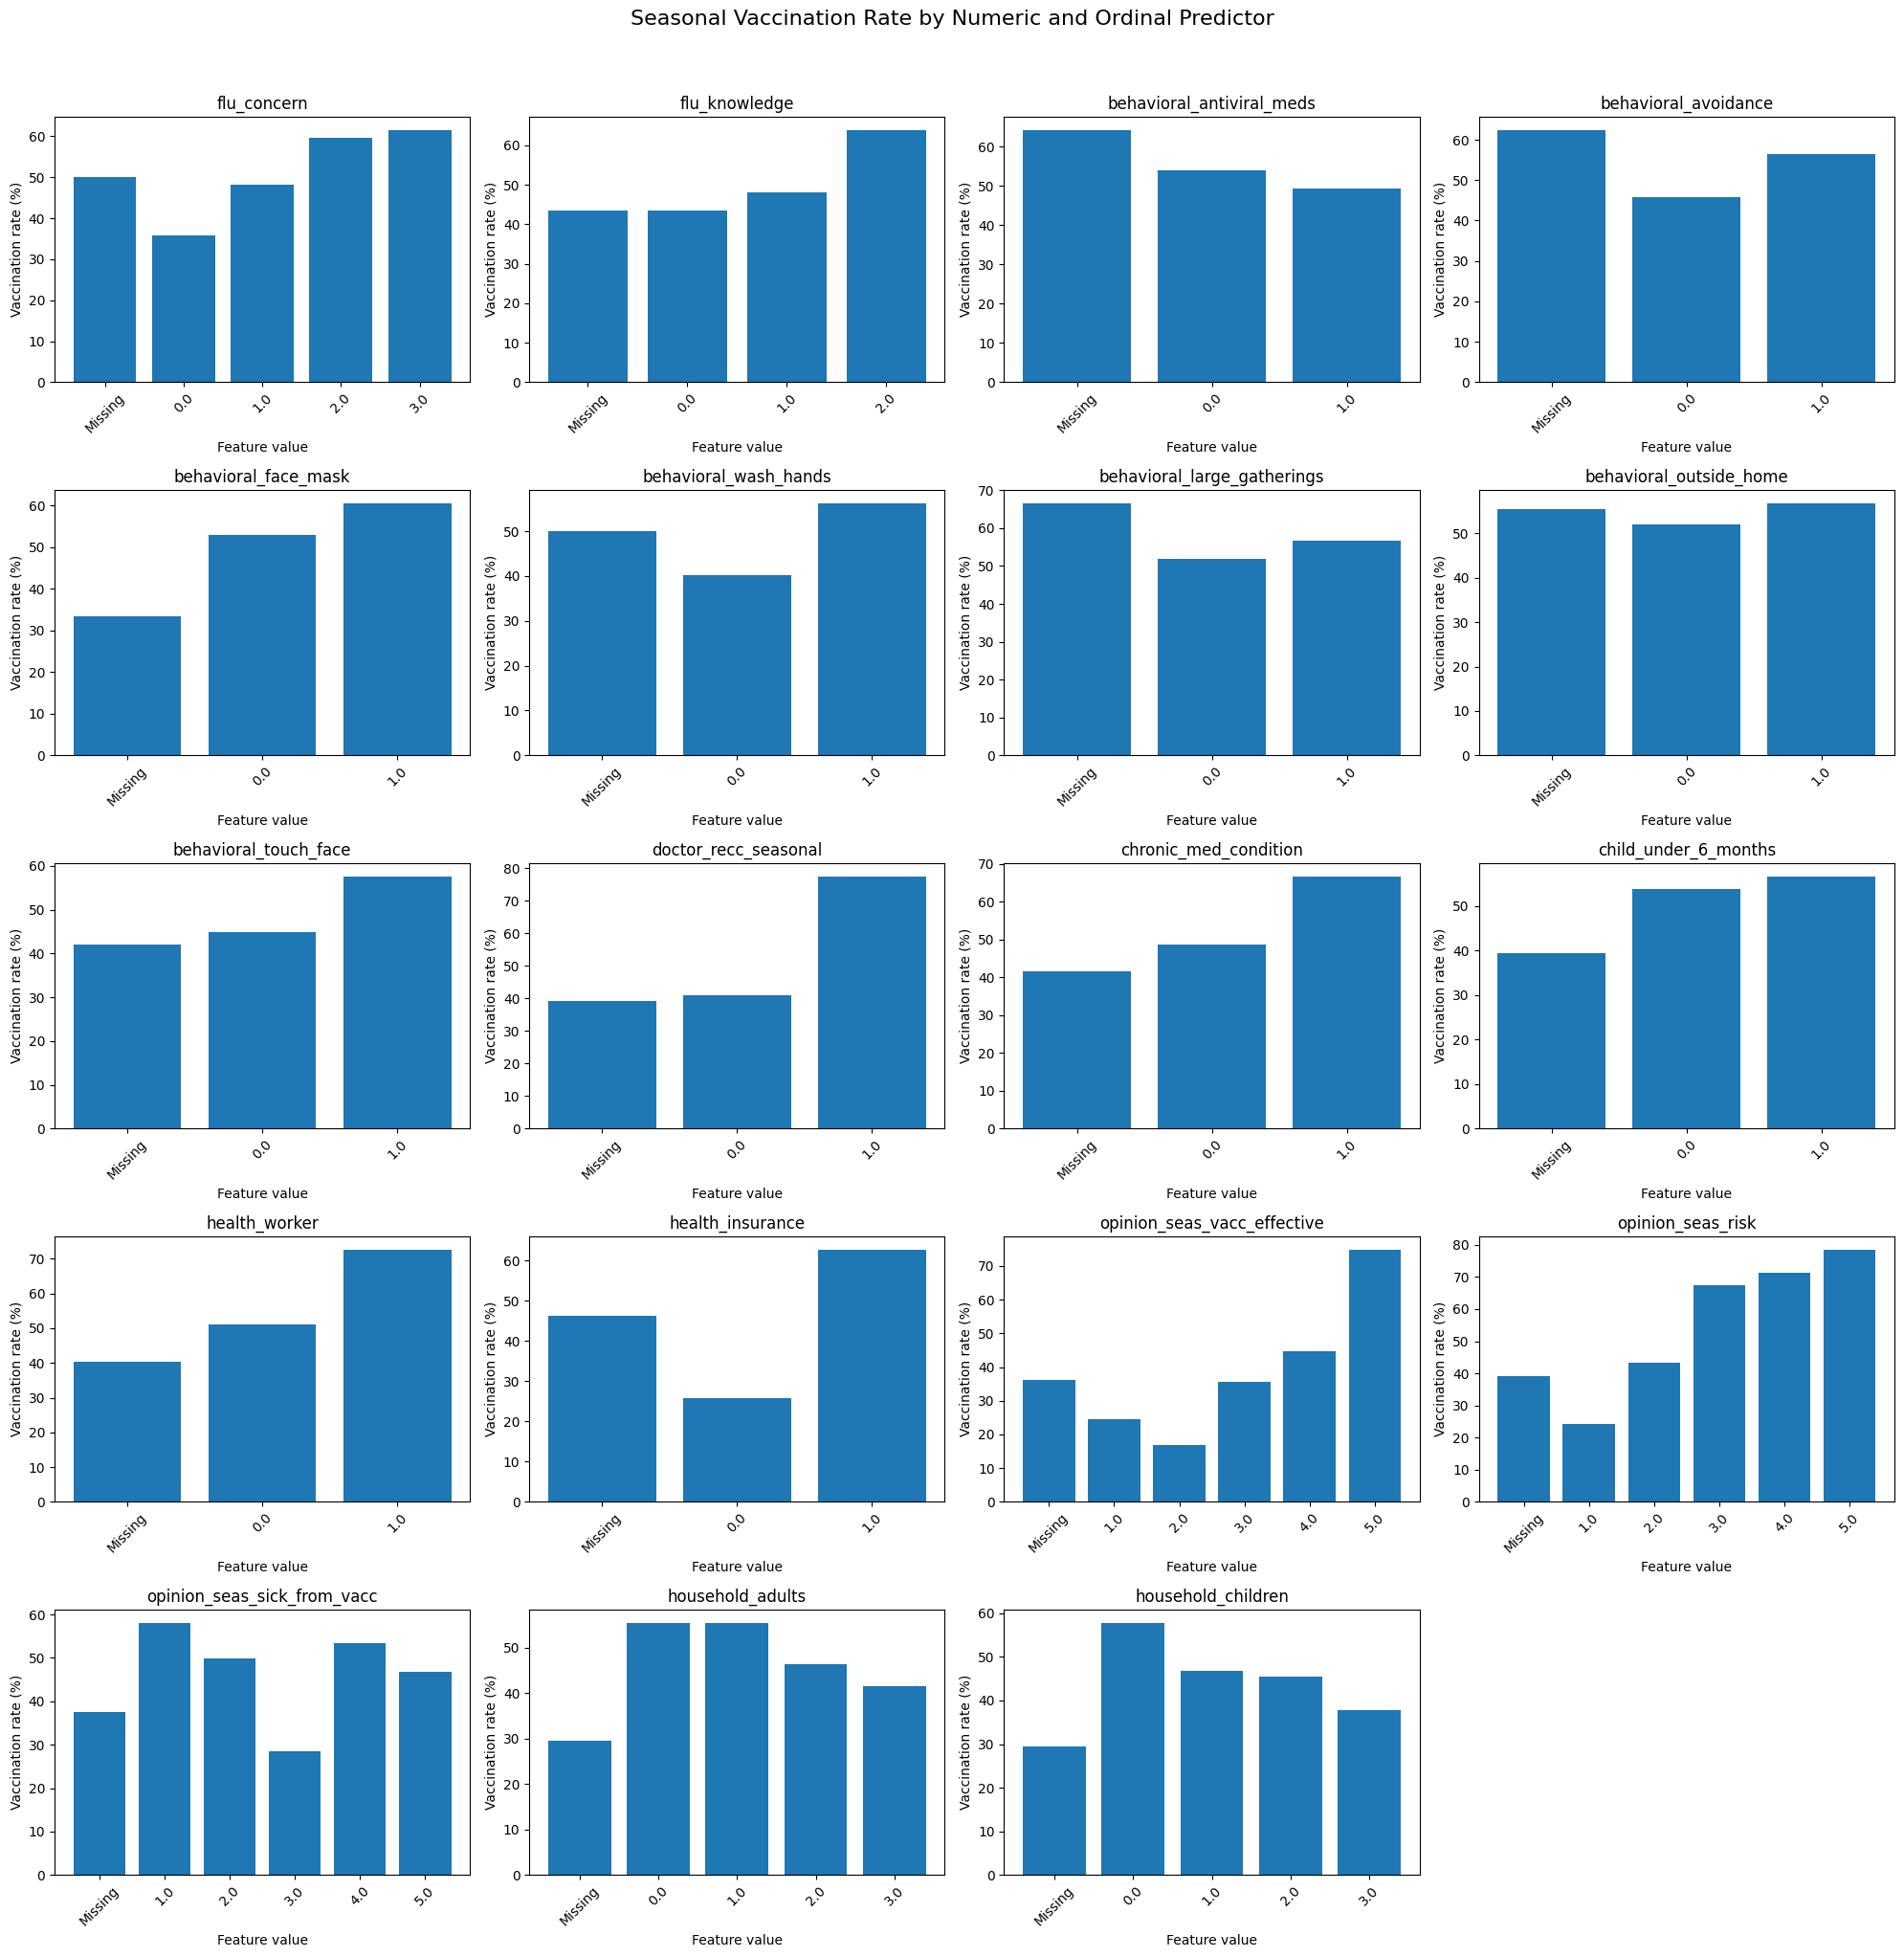

Saved: /content/drive/MyDrive/Hackathon/EDA/13_vaccination_rate_by_numeric_feature.png


In [21]:
# ------------------------------------------------------------
# 19. TARGET RATE BY NUMERIC OR ORDINAL FEATURE
# ------------------------------------------------------------
discrete_numeric_columns = [
    column
    for column in numeric_columns
    if X[column].nunique(dropna=True) <= 12
]

fig, axes = create_axes(
    number_of_plots=len(discrete_numeric_columns),
    columns=4,
    width=5,
    height=4
)

numeric_rate_tables = []

for axis, column in zip(axes, discrete_numeric_columns):

    analysis_df = pd.DataFrame({
        column: X[column].fillna(-999),
        TARGET_COLUMN: y
    })

    vaccination_rate = (
        analysis_df
        .groupby(column)[TARGET_COLUMN]
        .agg(["mean", "count"])
        .sort_index()
    )

    vaccination_rate["vaccination_rate_percentage"] = (
        vaccination_rate["mean"] * 100
    ).round(2)

    vaccination_rate["feature"] = column

    numeric_rate_tables.append(
        vaccination_rate.reset_index()
    )

    display_labels = [
        "Missing" if value == -999 else str(value)
        for value in vaccination_rate.index
    ]

    axis.bar(
        display_labels,
        vaccination_rate["vaccination_rate_percentage"]
    )

    axis.set_title(column)
    axis.set_xlabel("Feature value")
    axis.set_ylabel("Vaccination rate (%)")
    axis.tick_params(
        axis="x",
        rotation=45
    )

remove_unused_axes(
    axes,
    len(discrete_numeric_columns)
)

plt.suptitle(
    "Seasonal Vaccination Rate by Numeric and Ordinal Predictor",
    fontsize=16,
    y=1.02
)

save_and_show("13_vaccination_rate_by_numeric_feature.png")

numeric_rate_summary = pd.concat(
    numeric_rate_tables,
    ignore_index=True
)

numeric_rate_summary.to_csv(
    f"{EDA_FOLDER}/14_vaccination_rate_by_numeric_feature.csv",
    index=False
)


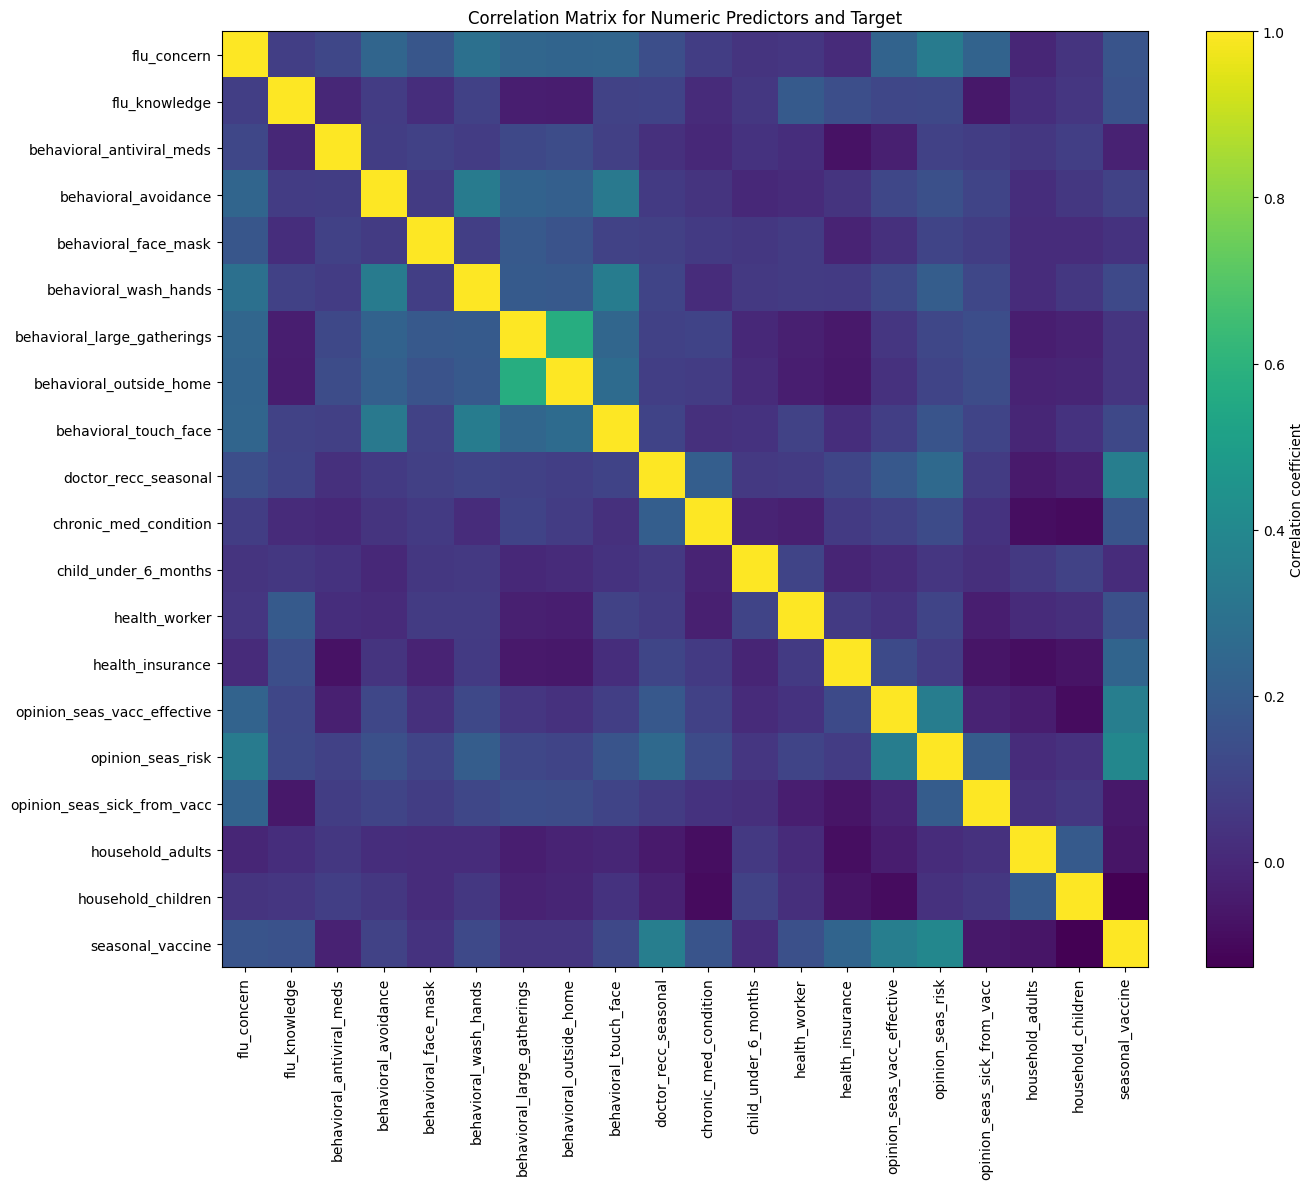

Saved: /content/drive/MyDrive/Hackathon/EDA/16_numeric_correlation_heatmap.png


In [22]:
# ------------------------------------------------------------
# 20. CORRELATION MATRIX INCLUDING TARGET
# ------------------------------------------------------------
correlation_df = X[numeric_columns].copy()
correlation_df[TARGET_COLUMN] = y

correlation_matrix = correlation_df.corr()

correlation_matrix.to_csv(
    f"{EDA_FOLDER}/15_numeric_correlation_matrix.csv",
    index=True
)

plt.figure(figsize=(14, 12))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation coefficient"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Matrix for Numeric Predictors and Target")

save_and_show("16_numeric_correlation_heatmap.png")

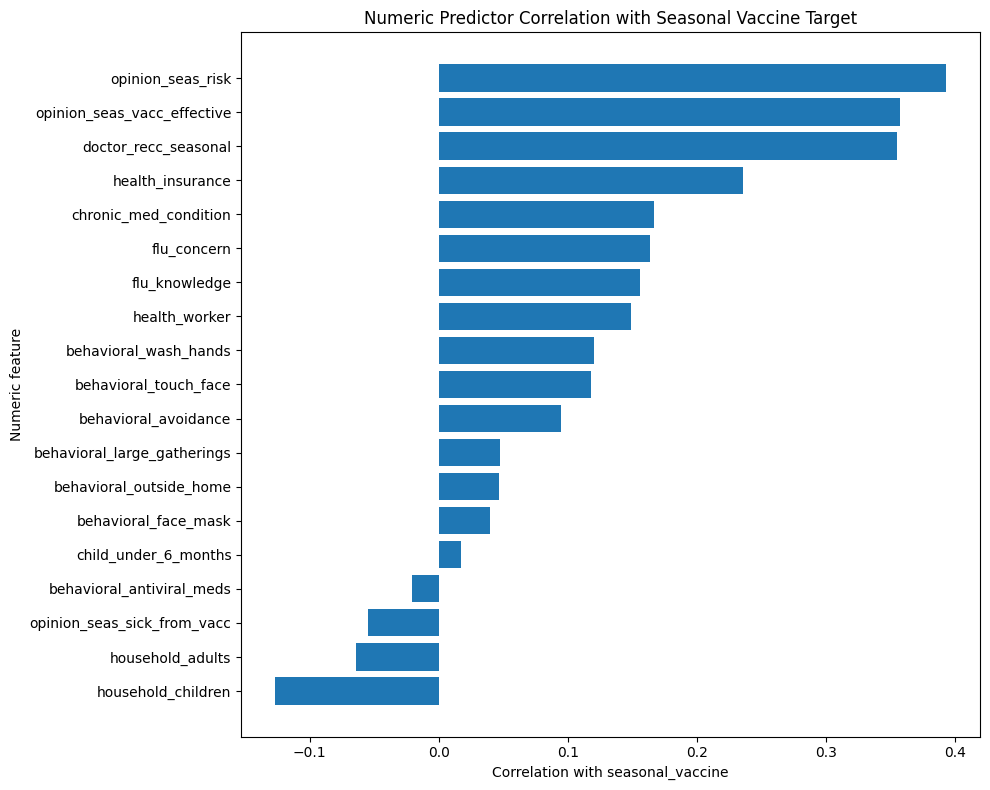

Saved: /content/drive/MyDrive/Hackathon/EDA/18_numeric_correlations_with_target.png


In [23]:
# ------------------------------------------------------------
# 21. NUMERIC CORRELATION WITH TARGET
# ------------------------------------------------------------
target_correlations = (
    correlation_matrix[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values()
)

target_correlations.to_csv(
    f"{EDA_FOLDER}/17_numeric_correlations_with_target.csv",
    index=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    target_correlations.index,
    target_correlations.values
)

plt.xlabel("Correlation with seasonal_vaccine")
plt.ylabel("Numeric feature")
plt.title("Numeric Predictor Correlation with Seasonal Vaccine Target")

save_and_show("18_numeric_correlations_with_target.png")

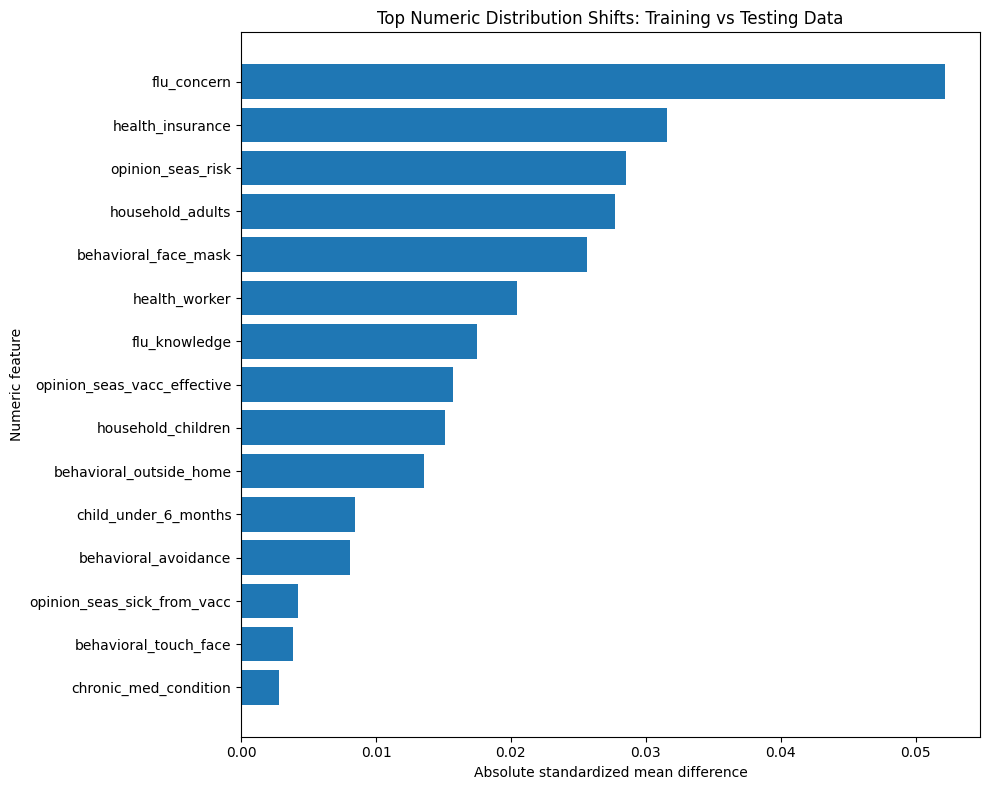

Saved: /content/drive/MyDrive/Hackathon/EDA/20_numeric_train_test_distribution_shift.png


In [24]:
# ------------------------------------------------------------
# 22. TRAINING VS TESTING DISTRIBUTION SHIFT:
# NUMERIC FEATURES
# ------------------------------------------------------------
numeric_shift_rows = []

for column in numeric_columns:

    training_mean = X[column].mean()
    testing_mean = X_test[column].mean()

    training_std = X[column].std()
    testing_std = X_test[column].std()

    pooled_std = np.sqrt(
        (training_std ** 2 + testing_std ** 2) / 2
    )

    if pooled_std == 0 or np.isnan(pooled_std):
        standardized_mean_difference = 0
    else:
        standardized_mean_difference = (
            abs(training_mean - testing_mean) /
            pooled_std
        )

    numeric_shift_rows.append({
        "feature": column,
        "training_mean": training_mean,
        "testing_mean": testing_mean,
        "absolute_standardized_mean_difference":
            standardized_mean_difference
    })

numeric_shift_summary = pd.DataFrame(
    numeric_shift_rows
).sort_values(
    by="absolute_standardized_mean_difference",
    ascending=False
)

numeric_shift_summary.to_csv(
    f"{EDA_FOLDER}/19_numeric_train_test_distribution_shift.csv",
    index=False
)

plt.figure(figsize=(10, 8))

top_numeric_shift = numeric_shift_summary.head(15).sort_values(
    by="absolute_standardized_mean_difference"
)

plt.barh(
    top_numeric_shift["feature"],
    top_numeric_shift["absolute_standardized_mean_difference"]
)

plt.xlabel("Absolute standardized mean difference")
plt.ylabel("Numeric feature")
plt.title("Top Numeric Distribution Shifts: Training vs Testing Data")

save_and_show("20_numeric_train_test_distribution_shift.png")

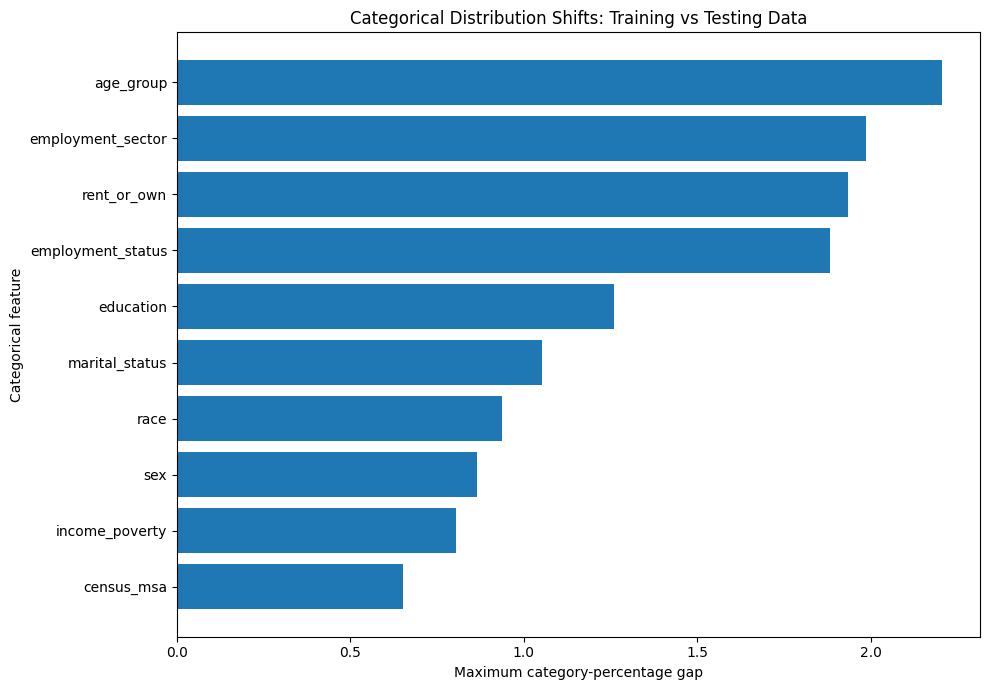

Saved: /content/drive/MyDrive/Hackathon/EDA/22_categorical_train_test_distribution_shift.png


In [25]:
# ------------------------------------------------------------
# 23. TRAINING VS TESTING DISTRIBUTION SHIFT:
# CATEGORICAL FEATURES
# ------------------------------------------------------------
categorical_shift_rows = []

for column in categorical_columns:

    training_proportions = (
        X[column]
        .fillna("Missing")
        .astype(str)
        .value_counts(normalize=True)
    )

    testing_proportions = (
        X_test[column]
        .fillna("Missing")
        .astype(str)
        .value_counts(normalize=True)
    )

    all_categories = (
        training_proportions.index
        .union(testing_proportions.index)
    )

    training_proportions = training_proportions.reindex(
        all_categories,
        fill_value=0
    )

    testing_proportions = testing_proportions.reindex(
        all_categories,
        fill_value=0
    )

    maximum_percentage_gap = (
        abs(
            training_proportions -
            testing_proportions
        ).max() * 100
    )

    categorical_shift_rows.append({
        "feature": column,
        "maximum_category_percentage_gap":
            round(maximum_percentage_gap, 4)
    })

categorical_shift_summary = pd.DataFrame(
    categorical_shift_rows
).sort_values(
    by="maximum_category_percentage_gap",
    ascending=False
)

categorical_shift_summary.to_csv(
    f"{EDA_FOLDER}/21_categorical_train_test_distribution_shift.csv",
    index=False
)

plt.figure(figsize=(10, 7))

top_categorical_shift = categorical_shift_summary.sort_values(
    by="maximum_category_percentage_gap"
)

plt.barh(
    top_categorical_shift["feature"],
    top_categorical_shift["maximum_category_percentage_gap"]
)

plt.xlabel("Maximum category-percentage gap")
plt.ylabel("Categorical feature")
plt.title("Categorical Distribution Shifts: Training vs Testing Data")

save_and_show("22_categorical_train_test_distribution_shift.png")


In [26]:

# ------------------------------------------------------------
# 24. SAVE DATASET OVERVIEW
# ------------------------------------------------------------
dataset_overview = pd.DataFrame({
    "metric": [
        "Training rows",
        "Testing rows",
        "Training columns",
        "Testing columns",
        "Predictor columns",
        "Numeric predictors",
        "Categorical predictors",
        "Training missing predictor values",
        "Testing missing predictor values",
        "Duplicate training respondent IDs",
        "Duplicate testing respondent IDs",
        "Target class 0 count",
        "Target class 1 count",
        "Target class 0 percentage",
        "Target class 1 percentage"
    ],

    "value": [
        len(train_df),
        len(test_df),
        train_df.shape[1],
        test_df.shape[1],
        X.shape[1],
        len(numeric_columns),
        len(categorical_columns),
        int(X.isnull().sum().sum()),
        int(X_test.isnull().sum().sum()),
        int(train_df[ID_COLUMN].duplicated().sum()),
        int(test_df[ID_COLUMN].duplicated().sum()),
        int((y == 0).sum()),
        int((y == 1).sum()),
        round((y == 0).mean() * 100, 2),
        round((y == 1).mean() * 100, 2)
    ]
})

dataset_overview.to_csv(
    f"{EDA_FOLDER}/23_dataset_overview.csv",
    index=False
)

print("\n============================================================")
print("EDA COMPLETED SUCCESSFULLY")
print("============================================================")

print("\nDataset overview:")
print(dataset_overview.to_string(index=False))

print("\nEDA output folder:")
print(EDA_FOLDER)

print("\nSaved CSV files:")
print("01_data_quality_report.csv")
print("02_missing_values_summary.csv")
print("05_target_distribution.csv")
print("07_numeric_summary_statistics.csv")
print("08_categorical_summary_statistics.csv")
print("12_vaccination_rate_by_categorical_feature.csv")
print("14_vaccination_rate_by_numeric_feature.csv")
print("15_numeric_correlation_matrix.csv")
print("17_numeric_correlations_with_target.csv")
print("19_numeric_train_test_distribution_shift.csv")
print("21_categorical_train_test_distribution_shift.csv")
print("23_dataset_overview.csv")

print("\nSaved figures:")
print("03_missing_values_training_vs_testing.png")
print("04_training_missing_percentage.png")
print("06_target_distribution.png")
print("09_numeric_feature_distributions.png")
print("10_categorical_feature_distributions.png")
print("11_vaccination_rate_by_categorical_feature.png")
print("13_vaccination_rate_by_numeric_feature.png")
print("16_numeric_correlation_heatmap.png")
print("18_numeric_correlations_with_target.png")
print("20_numeric_train_test_distribution_shift.png")
print("22_categorical_train_test_distribution_shift.png")


EDA COMPLETED SUCCESSFULLY

Dataset overview:
                           metric   value
                    Training rows 4756.00
                     Testing rows 4749.00
                 Training columns   31.00
                  Testing columns   30.00
                Predictor columns   29.00
               Numeric predictors   19.00
           Categorical predictors   10.00
Training missing predictor values 7538.00
 Testing missing predictor values 7772.00
Duplicate training respondent IDs    0.00
 Duplicate testing respondent IDs    0.00
             Target class 0 count 2205.00
             Target class 1 count 2551.00
        Target class 0 percentage   46.36
        Target class 1 percentage   53.64

EDA output folder:
/content/drive/MyDrive/Hackathon/EDA

Saved CSV files:
01_data_quality_report.csv
02_missing_values_summary.csv
05_target_distribution.csv
07_numeric_summary_statistics.csv
08_categorical_summary_statistics.csv
12_vaccination_rate_by_categorical_feature.csv
14_

Training predictors: (4756, 29)
Testing predictors : (4749, 29)
Numeric columns    : 19
Categorical columns: 10

Training split  : (3804, 29)
Validation split: (952, 29)

TUNING: Logistic Regression KNN5
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best cross-validation ROC-AUC: 0.841593
Validation accuracy: 0.773109
Validation ROC-AUC: 0.841958
Validation F1 score: 0.787402

Best parameters:
{'classifier__solver': 'liblinear', 'classifier__class_weight': None, 'classifier__C': 0.01}

TUNING: Extra Trees KNN5
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best cross-validation ROC-AUC: 0.842763
Validation accuracy: 0.771008
Validation ROC-AUC: 0.841483
Validation F1 score: 0.786693

Best parameters:
{'classifier__n_estimators': 500, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 10, 'classifier__class_weight': None}

TUNING: Random Forest KNN5
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best cross-validation ROC-AUC: 0.8442

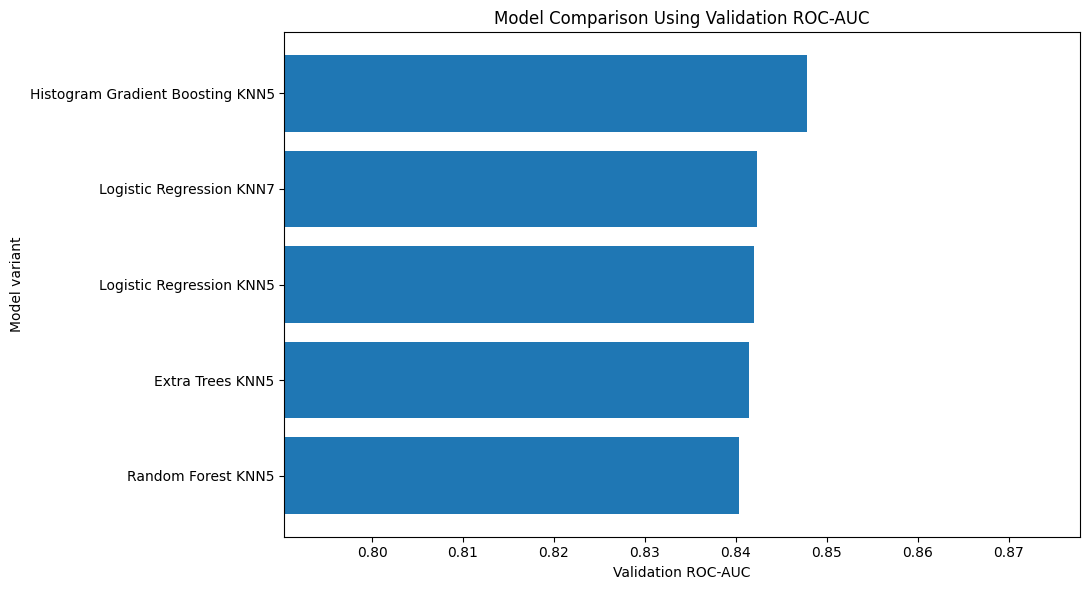


Retraining full dataset: Histogram Gradient Boosting KNN5

Retraining full dataset: Logistic Regression KNN7

Retraining full dataset: Logistic Regression KNN5

Retraining full dataset: Extra Trees KNN5

Retraining full dataset: Random Forest KNN5

TOP-5 SUBMISSION FILES CREATED
 rank                            model  validation_roc_auc                        submission_file                                        probability_file  predicted_0_count  predicted_1_count
    1 Histogram Gradient Boosting KNN5            0.847860 1_histogram_gradient_boosting_knn5.csv 1_histogram_gradient_boosting_knn5_with_probability.csv               2062               2687
    2         Logistic Regression KNN7            0.842295         2_logistic_regression_knn7.csv         2_logistic_regression_knn7_with_probability.csv               2070               2679
    3         Logistic Regression KNN5            0.841958         3_logistic_regression_knn5.csv         3_logistic_regression_knn5_with_proba

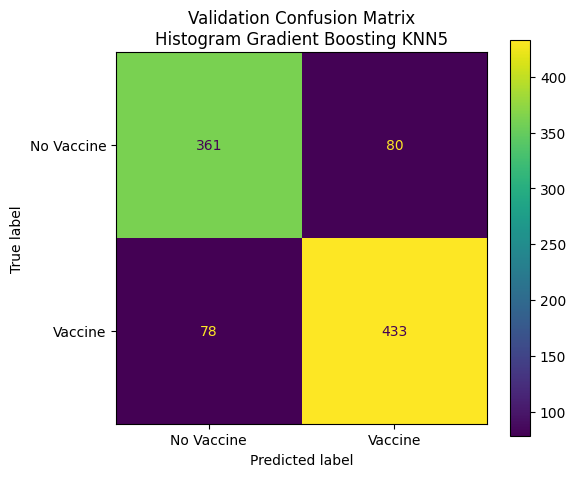

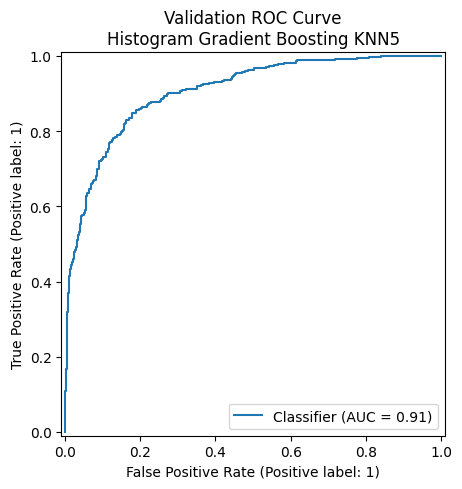


MODELLING SECTION COMPLETED SUCCESSFULLY

Model comparison table:
/content/drive/MyDrive/Hackathon/Modelling/model_tuning_comparison.csv

Model comparison plot:
/content/drive/MyDrive/Hackathon/Modelling/model_comparison_roc_auc.png

Ranked submission folder:
/content/drive/MyDrive/Hackathon/Submissions

Submission manifest:
/content/drive/MyDrive/Hackathon/Submissions/submission_manifest.csv

Best-model confusion matrix:
/content/drive/MyDrive/Hackathon/Modelling/best_model_confusion_matrix.png

Best-model ROC curve:
/content/drive/MyDrive/Hackathon/Modelling/best_model_roc_curve.png


In [27]:
# ============================================================
# MODEL COMPARISON, HYPERPARAMETER TUNING AND TOP-5 SUBMISSIONS
# Run this cell after EDA and preprocessing
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------------------
MODELLING_FOLDER = f"{BASE_FOLDER}/Modelling"
SUBMISSION_FOLDER = f"{BASE_FOLDER}/Submissions"

os.makedirs(MODELLING_FOLDER, exist_ok=True)
os.makedirs(SUBMISSION_FOLDER, exist_ok=True)

RANDOM_STATE = 42

# ------------------------------------------------------------
# 2. RECREATE FEATURE TYPES
# Uses X, y and X_test from your previous EDA/preprocessing cells
# ------------------------------------------------------------
numeric_columns = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    exclude=["number"]
).columns.tolist()

test_ids = test_df[ID_COLUMN].copy()

print("Training predictors:", X.shape)
print("Testing predictors :", X_test.shape)
print("Numeric columns    :", len(numeric_columns))
print("Categorical columns:", len(categorical_columns))

# ------------------------------------------------------------
# 3. PREPROCESSING PIPELINE
# KNN imputation remains inside each model pipeline
# ------------------------------------------------------------
feature_encoder = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_columns
        ),
        (
            "categorical",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                encoded_missing_value=np.nan
            ),
            categorical_columns
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

def create_pipeline(model, n_neighbors=5, weights="distance"):
    """
    Build a complete modelling pipeline:
    encoding -> scaling -> KNN imputation -> classifier
    """
    return Pipeline(
        steps=[
            (
                "encode_features",
                clone(feature_encoder)
            ),
            (
                "scale_features",
                StandardScaler()
            ),
            (
                "knn_imputation",
                KNNImputer(
                    n_neighbors=n_neighbors,
                    weights=weights
                )
            ),
            (
                "classifier",
                model
            )
        ]
    )

# ------------------------------------------------------------
# 4. STRATIFIED TRAIN-VALIDATION SPLIT
# Hold-out data is used for final comparison after tuning
# ------------------------------------------------------------
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("\nTraining split  :", X_train.shape)
print("Validation split:", X_valid.shape)

# ------------------------------------------------------------
# 5. DEFINE FIVE DISTINCT MODEL VARIANTS
# ------------------------------------------------------------
candidate_models = {

    "Logistic Regression KNN5": {
        "pipeline": create_pipeline(
            LogisticRegression(
                max_iter=5000,
                random_state=RANDOM_STATE
            ),
            n_neighbors=5,
            weights="distance"
        ),
        "parameters": {
            "classifier__C": [0.01, 0.1, 0.5, 1, 2, 5, 10, 100],
            "classifier__class_weight": [None, "balanced"],
            "classifier__solver": ["liblinear", "lbfgs"]
        },
        "iterations": 10
    },

    "Extra Trees KNN5": {
        "pipeline": create_pipeline(
            ExtraTreesClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1
            ),
            n_neighbors=5,
            weights="distance"
        ),
        "parameters": {
            "classifier__n_estimators": [300, 500, 800],
            "classifier__max_depth": [None, 10, 20, 30],
            "classifier__min_samples_leaf": [1, 2, 4],
            "classifier__class_weight": [None, "balanced"]
        },
        "iterations": 10
    },

    "Random Forest KNN5": {
        "pipeline": create_pipeline(
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1
            ),
            n_neighbors=5,
            weights="distance"
        ),
        "parameters": {
            "classifier__n_estimators": [300, 500, 800],
            "classifier__max_depth": [None, 10, 20, 30],
            "classifier__min_samples_leaf": [1, 2, 4],
            "classifier__class_weight": [None, "balanced_subsample"]
        },
        "iterations": 10
    },

    "Logistic Regression KNN7": {
        "pipeline": create_pipeline(
            LogisticRegression(
                max_iter=5000,
                random_state=RANDOM_STATE
            ),
            n_neighbors=7,
            weights="distance"
        ),
        "parameters": {
            "classifier__C": [0.01, 0.1, 0.5, 1, 2, 5, 10, 100],
            "classifier__class_weight": [None, "balanced"],
            "classifier__solver": ["liblinear", "lbfgs"]
        },
        "iterations": 10
    },

    "Histogram Gradient Boosting KNN5": {
        "pipeline": create_pipeline(
            HistGradientBoostingClassifier(
                random_state=RANDOM_STATE
            ),
            n_neighbors=5,
            weights="distance"
        ),
        "parameters": {
            "classifier__learning_rate": [0.03, 0.05, 0.1],
            "classifier__max_iter": [200, 350, 500],
            "classifier__max_leaf_nodes": [15, 31, 63],
            "classifier__l2_regularization": [0.0, 0.1, 1.0]
        },
        "iterations": 10
    }
}

# ------------------------------------------------------------
# 6. HYPERPARAMETER TUNING
# Models are tuned using cross-validation ROC-AUC
# ------------------------------------------------------------
results = []
best_estimators = {}

for model_name, model_info in candidate_models.items():

    print("\n============================================================")
    print("TUNING:", model_name)
    print("============================================================")

    search = RandomizedSearchCV(
        estimator=model_info["pipeline"],
        param_distributions=model_info["parameters"],
        n_iter=model_info["iterations"],
        scoring="roc_auc",
        cv=cv_strategy,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    search.fit(
        X_train,
        y_train
    )

    best_pipeline = search.best_estimator_

    validation_predictions = best_pipeline.predict(
        X_valid
    )

    validation_probabilities = best_pipeline.predict_proba(
        X_valid
    )[:, 1]

    validation_accuracy = accuracy_score(
        y_valid,
        validation_predictions
    )

    validation_roc_auc = roc_auc_score(
        y_valid,
        validation_probabilities
    )

    validation_f1 = f1_score(
        y_valid,
        validation_predictions
    )

    results.append({
        "model": model_name,
        "cross_validation_roc_auc": round(
            search.best_score_,
            6
        ),
        "validation_accuracy": round(
            validation_accuracy,
            6
        ),
        "validation_roc_auc": round(
            validation_roc_auc,
            6
        ),
        "validation_f1_score": round(
            validation_f1,
            6
        ),
        "best_parameters": str(
            search.best_params_
        )
    })

    best_estimators[model_name] = best_pipeline

    print("\nBest cross-validation ROC-AUC:",
          round(search.best_score_, 6))

    print("Validation accuracy:",
          round(validation_accuracy, 6))

    print("Validation ROC-AUC:",
          round(validation_roc_auc, 6))

    print("Validation F1 score:",
          round(validation_f1, 6))

    print("\nBest parameters:")
    print(search.best_params_)

# ------------------------------------------------------------
# 7. RANK MODELS
# Validation ROC-AUC is used as the main ranking measure
# ------------------------------------------------------------
results_df = pd.DataFrame(
    results
).sort_values(
    by=[
        "validation_roc_auc",
        "cross_validation_roc_auc"
    ],
    ascending=False
).reset_index(drop=True)

results_df.insert(
    0,
    "rank",
    np.arange(1, len(results_df) + 1)
)

RESULTS_PATH = (
    f"{MODELLING_FOLDER}/model_tuning_comparison.csv"
)

results_df.to_csv(
    RESULTS_PATH,
    index=False
)

print("\n============================================================")
print("FINAL MODEL RANKING")
print("============================================================")

print(
    results_df[
        [
            "rank",
            "model",
            "cross_validation_roc_auc",
            "validation_accuracy",
            "validation_roc_auc",
            "validation_f1_score"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 8. MODEL-COMPARISON PLOT
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))

ranking_plot = results_df.sort_values(
    by="validation_roc_auc"
)

plt.barh(
    ranking_plot["model"],
    ranking_plot["validation_roc_auc"]
)

plt.xlabel("Validation ROC-AUC")
plt.ylabel("Model variant")
plt.title("Model Comparison Using Validation ROC-AUC")
plt.xlim(
    max(0, ranking_plot["validation_roc_auc"].min() - 0.05),
    min(1, ranking_plot["validation_roc_auc"].max() + 0.03)
)

plt.tight_layout()

MODEL_COMPARISON_PLOT_PATH = (
    f"{MODELLING_FOLDER}/model_comparison_roc_auc.png"
)

plt.savefig(
    MODEL_COMPARISON_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 9. RETRAIN EACH RANKED MODEL AND CREATE FIVE SUBMISSIONS
# ------------------------------------------------------------
submission_manifest = []

for row_number, row in results_df.iterrows():

    rank = int(row["rank"])
    model_name = row["model"]

    print("\nRetraining full dataset:", model_name)

    final_pipeline = best_estimators[model_name]

    final_pipeline.fit(
        X,
        y
    )

    test_probabilities = final_pipeline.predict_proba(
        X_test
    )[:, 1]

    test_predictions = (
        test_probabilities >= 0.50
    ).astype(int)

    safe_model_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    submission_filename = (
        f"{rank}_{safe_model_name}.csv"
    )

    submission_path = (
        f"{SUBMISSION_FOLDER}/{submission_filename}"
    )

    probability_filename = (
        f"{rank}_{safe_model_name}_with_probability.csv"
    )

    probability_path = (
        f"{SUBMISSION_FOLDER}/{probability_filename}"
    )

    submission_df = pd.DataFrame({
        ID_COLUMN: test_ids,
        TARGET_COLUMN: test_predictions
    })

    probability_df = pd.DataFrame({
        ID_COLUMN: test_ids,
        "seasonal_vaccine_probability":
            test_probabilities,
        TARGET_COLUMN: test_predictions
    })

    if submission_df.shape != (
        len(X_test),
        2
    ):
        raise ValueError(
            f"Unexpected submission shape for {model_name}: "
            f"{submission_df.shape}"
        )

    if submission_df[TARGET_COLUMN].isnull().any():
        raise ValueError(
            f"Null predictions found for {model_name}."
        )

    if not set(
        submission_df[TARGET_COLUMN].unique()
    ).issubset({0, 1}):
        raise ValueError(
            f"Invalid predictions found for {model_name}."
        )

    submission_df.to_csv(
        submission_path,
        index=False
    )

    probability_df.to_csv(
        probability_path,
        index=False
    )

    submission_manifest.append({
        "rank": rank,
        "model": model_name,
        "validation_roc_auc":
            row["validation_roc_auc"],
        "submission_file":
            submission_filename,
        "probability_file":
            probability_filename,
        "predicted_0_count":
            int((test_predictions == 0).sum()),
        "predicted_1_count":
            int((test_predictions == 1).sum())
    })

submission_manifest_df = pd.DataFrame(
    submission_manifest
)

SUBMISSION_MANIFEST_PATH = (
    f"{SUBMISSION_FOLDER}/submission_manifest.csv"
)

submission_manifest_df.to_csv(
    SUBMISSION_MANIFEST_PATH,
    index=False
)

print("\n============================================================")
print("TOP-5 SUBMISSION FILES CREATED")
print("============================================================")

print(
    submission_manifest_df.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# 10. PERFORMANCE PLOTS FOR BEST MODEL
# ------------------------------------------------------------
best_model_name = results_df.loc[0, "model"]

best_validation_pipeline = (
    best_estimators[best_model_name]
)

best_validation_predictions = (
    best_validation_pipeline.predict(
        X_valid
    )
)

best_validation_probabilities = (
    best_validation_pipeline.predict_proba(
        X_valid
    )[:, 1]
)

print("\n============================================================")
print("BEST MODEL CLASSIFICATION REPORT")
print("============================================================")

print("Best model:", best_model_name)

print(
    classification_report(
        y_valid,
        best_validation_predictions,
        digits=4
    )
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    best_validation_predictions,
    display_labels=[
        "No Vaccine",
        "Vaccine"
    ],
    ax=ax
)

ax.set_title(
    f"Validation Confusion Matrix\n{best_model_name}"
)

fig.tight_layout()

CONFUSION_MATRIX_PATH = (
    f"{MODELLING_FOLDER}/best_model_confusion_matrix.png"
)

fig.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

fig, ax = plt.subplots(
    figsize=(6, 5)
)

RocCurveDisplay.from_predictions(
    y_valid,
    best_validation_probabilities,
    ax=ax
)

ax.set_title(
    f"Validation ROC Curve\n{best_model_name}"
)

fig.tight_layout()

ROC_CURVE_PATH = (
    f"{MODELLING_FOLDER}/best_model_roc_curve.png"
)

fig.savefig(
    ROC_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 11. FINAL SUMMARY
# ------------------------------------------------------------
print("\n============================================================")
print("MODELLING SECTION COMPLETED SUCCESSFULLY")
print("============================================================")

print("\nModel comparison table:")
print(RESULTS_PATH)

print("\nModel comparison plot:")
print(MODEL_COMPARISON_PLOT_PATH)

print("\nRanked submission folder:")
print(SUBMISSION_FOLDER)

print("\nSubmission manifest:")
print(SUBMISSION_MANIFEST_PATH)

print("\nBest-model confusion matrix:")
print(CONFUSION_MATRIX_PATH)

print("\nBest-model ROC curve:")
print(ROC_CURVE_PATH)